# 가스터빈 이론

## Brayton Cycle (Ideal Gas Turbine) 요약

### 1) 이상적 열역학 사이클
- **1→2 등엔트로피 압축 (Compressor)**: 공기를 압축하여 압력/온도 상승
- **2→3 정압 열추가 (Combustor)**: 연료 연소로 온도 급상승 (압력은 거의 일정)
- **3→4 등엔트로피 팽창 (Turbine)**: 가스 팽창으로 축동력 생산
- **4→1 정압 열방출/배기**: 실제 가스터빈은 개방 사이클로 배기가스 배출

### 2) 핵심 식
- 열효율(이상 브라이턴, 등엔트로피 가정):
  $$\eta_{th}=1-\frac{1}{PR^{(\gamma-1)/\gamma}}$$
- 순일률:
  $$W_{net}=W_{turbine}-W_{compressor}=\dot m c_p\left[(T_3-T_4)-(T_2-T_1)\right]$$
- 예시: $PR=8.0$, $\gamma=1.4$이면 이상 열효율은 약 $44.8\%$

### 3) VHDL-AMS 모델 대응
- **Inlet + Compressor**: 압축 과정 ($T_1\to T_2$, $P_1\to P_2$)
- **Combustor**: 정압 열추가 ($T_2\to T_3$, `comb_ref` 기준)
- **Turbine + Shaft**: 팽창/동력 추출 ($T_3\to T_4$, 회전속도 $\omega$ 동역학)
- 이상 브라이턴의 4개 과정이 VHDL-AMS 컴포넌트 동작과 직접 대응됨

아래 코드는 슬라이더로 $PR, \gamma, T_1, T_3, c_p, \dot m$를 바꾸면서 **T-s**와 **P-v** 곡선을 인터랙티브로 확인합니다.

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def brayton_states(pr=8.0, gamma=1.4, t1=300.0, t3=1400.0, p1=1.0):
    """Return ideal Brayton state variables for points 1-4."""
    p2 = p1 * pr
    p3 = p2
    p4 = p1

    t2 = t1 * pr ** ((gamma - 1.0) / gamma)
    t4 = t3 / pr ** ((gamma - 1.0) / gamma)

    return {
        "T": np.array([t1, t2, t3, t4], dtype=float),
        "P": np.array([p1, p2, p3, p4], dtype=float),
    }


def build_cycle_curves(pr, gamma, t1, t3, cp, m_dot):
    states = brayton_states(pr=pr, gamma=gamma, t1=t1, t3=t3, p1=1.0)
    T = states["T"]
    P = states["P"]

    # Ideal-gas relation: R = cp*(gamma-1)/gamma
    R = cp * (gamma - 1.0) / gamma

    # Entropy (relative, s1=0)
    s1 = 0.0
    s2 = s1
    s3 = s2 + cp * np.log(T[2] / T[1])
    s4 = s3
    s = np.array([s1, s2, s3, s4], dtype=float)

    # Specific volume at state points (normalized pressure units)
    v = R * T / P

    # Process curves for smoother plotting
    n = 80

    # 1->2 isentropic: P*v^gamma = const
    p12 = np.linspace(P[0], P[1], n)
    c12 = P[0] * (v[0] ** gamma)
    v12 = (c12 / p12) ** (1.0 / gamma)
    t12 = p12 * v12 / R
    s12 = np.full_like(t12, s1)

    # 2->3 isobaric heating
    t23 = np.linspace(T[1], T[2], n)
    p23 = np.full_like(t23, P[1])
    s23 = s2 + cp * np.log(t23 / T[1])
    v23 = R * t23 / p23

    # 3->4 isentropic
    p34 = np.linspace(P[2], P[3], n)
    c34 = P[2] * (v[2] ** gamma)
    v34 = (c34 / p34) ** (1.0 / gamma)
    t34 = p34 * v34 / R
    s34 = np.full_like(t34, s3)

    # 4->1 isobaric heat rejection
    t41 = np.linspace(T[3], T[0], n)
    p41 = np.full_like(t41, P[3])
    s41 = s4 + cp * np.log(t41 / T[3])
    v41 = R * t41 / p41

    eta_th = 1.0 - 1.0 / (pr ** ((gamma - 1.0) / gamma))
    w_net = m_dot * cp * ((T[2] - T[3]) - (T[1] - T[0]))

    return {
        "T": T,
        "P": P,
        "s": s,
        "v": v,
        "segments": {
            "12": (s12, t12, p12, v12),
            "23": (s23, t23, p23, v23),
            "34": (s34, t34, p34, v34),
            "41": (s41, t41, p41, v41),
        },
        "eta": eta_th,
        "w_net": w_net,
    }


def plot_brayton(pr=8.0, gamma=1.4, t1=300.0, t3=1400.0, cp=1.005, m_dot=1.0):
    data = build_cycle_curves(pr, gamma, t1, t3, cp, m_dot)

    fig = make_subplots(rows=1, cols=2, subplot_titles=("T-s Diagram", "P-v Diagram"))

    # T-s curves
    for key, name in zip(["12", "23", "34", "41"], ["1→2", "2→3", "3→4", "4→1"]):
        s_seg, t_seg, _, _ = data["segments"][key]
        fig.add_trace(
            go.Scatter(x=s_seg, y=t_seg, mode="lines", name=f"{name} (T-s)"),
            row=1,
            col=1,
        )

    fig.add_trace(
        go.Scatter(
            x=data["s"],
            y=data["T"],
            mode="markers+text",
            text=["1", "2", "3", "4"],
            textposition="top center",
            name="States (T-s)",
            marker=dict(size=9),
        ),
        row=1,
        col=1,
    )

    # P-v curves
    for key, name in zip(["12", "23", "34", "41"], ["1→2", "2→3", "3→4", "4→1"]):
        _, _, p_seg, v_seg = data["segments"][key]
        fig.add_trace(
            go.Scatter(x=v_seg, y=p_seg, mode="lines", name=f"{name} (P-v)"),
            row=1,
            col=2,
        )

    fig.add_trace(
        go.Scatter(
            x=data["v"],
            y=data["P"],
            mode="markers+text",
            text=["1", "2", "3", "4"],
            textposition="top center",
            name="States (P-v)",
            marker=dict(size=9),
        ),
        row=1,
        col=2,
    )

    fig.update_xaxes(title_text="s [kJ/kg-K, relative]", row=1, col=1)
    fig.update_yaxes(title_text="T [K]", row=1, col=1)
    fig.update_xaxes(title_text="v [relative units]", row=1, col=2)
    fig.update_yaxes(title_text="P [bar, normalized]", row=1, col=2)

    fig.update_layout(
        width=1200,
        height=500,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
        title=(
            f"Ideal Brayton Cycle | PR={pr:.2f}, gamma={gamma:.3f}, "
            f"eta_th={100.0*data['eta']:.2f}% | W_net={data['w_net']:.2f} kW"
        ),
    )

    fig.show()


pr_slider = widgets.FloatSlider(value=8.0, min=2.0, max=30.0, step=0.5, description="PR")
gamma_slider = widgets.FloatSlider(value=1.4, min=1.25, max=1.67, step=0.01, description="gamma")
t1_slider = widgets.FloatSlider(value=300.0, min=250.0, max=450.0, step=5.0, description="T1 [K]")
t3_slider = widgets.FloatSlider(value=1400.0, min=900.0, max=2000.0, step=10.0, description="T3 [K]")
cp_slider = widgets.FloatSlider(value=1.005, min=0.9, max=1.3, step=0.005, description="cp")
mdot_slider = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description="m_dot")

ui = widgets.VBox(
    [
        widgets.HTML("<b>Interactive Brayton Cycle Controls</b>"),
        widgets.HBox([pr_slider, gamma_slider]),
        widgets.HBox([t1_slider, t3_slider]),
        widgets.HBox([cp_slider, mdot_slider]),
    ]
)

out = widgets.Output()


def _refresh(_=None):
    with out:
        clear_output(wait=True)
        plot_brayton(
            pr=pr_slider.value,
            gamma=gamma_slider.value,
            t1=t1_slider.value,
            t3=t3_slider.value,
            cp=cp_slider.value,
            m_dot=mdot_slider.value,
        )


for w in [pr_slider, gamma_slider, t1_slider, t3_slider, cp_slider, mdot_slider]:
    w.observe(_refresh, names="value")


display(ui, out)
_refresh()

Output()

## Brayton Cycle: 왜 T-S, P-V 곡선이 이렇게 그려지는가 (수식 기반)

가정:
$$
\text{ideal gas},\quad c_p,\gamma=\frac{c_p}{c_v}\text{ 일정},\quad R=c_p-c_v
$$

기본식:
$$
Pv=RT,\quad \Delta s=c_p\ln\frac{T_2}{T_1}-R\ln\frac{P_2}{P_1}
$$

### 1) 1→2 등엔트로피 압축 (Compressor)
등엔트로피 조건:
$$
s_2=s_1,\quad \frac{T_2}{T_1}=\left(\frac{P_2}{P_1}\right)^{(\gamma-1)/\gamma}
$$
또는
$$
Pv^\gamma=\text{const}
$$

해석:
- 압축되면서 $P$ 증가, $v$ 감소, $T$ 증가
- 엔트로피는 일정

그래프 모양:
- **T-S**: $s$ 일정이므로 수직선(위로)
- **P-V**: 단열압축 곡선(좌상향, 가파른 곡선)

### 2) 2→3 정압 열추가 (Combustor)
정압 조건:
$$
P_2=P_3,\quad \frac{v_3}{v_2}=\frac{T_3}{T_2}
$$

엔트로피 변화:
$$
\Delta s_{23}=s_3-s_2=c_p\ln\frac{T_3}{T_2}>0
$$

해석:
- 열추가로 $T$ 상승
- 압력은 거의 일정
- 엔트로피 증가

그래프 모양:
- **T-S**: 오른쪽으로 이동하며 위로 증가
- **P-V**: 압력 일정이므로 수평선(오른쪽)

### 3) 3→4 등엔트로피 팽창 (Turbine)
등엔트로피 조건:
$$
s_4=s_3,\quad \frac{T_4}{T_3}=\left(\frac{P_4}{P_3}\right)^{(\gamma-1)/\gamma}
$$
브레이턴에서 $P_3/P_4=PR$이면
$$
\frac{T_4}{T_3}=PR^{-(\gamma-1)/\gamma}
$$
또는
$$
Pv^\gamma=\text{const}
$$

해석:
- 팽창되며 $P$ 감소, $v$ 증가, $T$ 감소
- 엔트로피 일정

그래프 모양:
- **T-S**: 수직선(아래로)
- **P-V**: 단열팽창 곡선(우하향)

### 4) 4→1 정압 열방출 (Exhaust / Heat Rejection)
정압 조건:
$$
P_4=P_1,\quad \frac{v_1}{v_4}=\frac{T_1}{T_4}
$$

엔트로피 변화:
$$
\Delta s_{41}=s_1-s_4=c_p\ln\frac{T_1}{T_4}<0
$$

해석:
- 열방출로 $T$ 감소
- 압력 일정
- 엔트로피 감소

그래프 모양:
- **T-S**: 왼쪽으로 이동하며 아래로
- **P-V**: 수평선(왼쪽)

### 정리: 곡선 형태가 나오는 이유
1. 등엔트로피 두 과정(1→2, 3→4)은 T-S에서 수직선
2. 정압 두 과정(2→3, 4→1)은 P-V에서 수평선
3. 단열과정은 $Pv^\gamma=\text{const}$를 따라 P-V에서 곡선
4. 그래서 T-S와 P-V에서 현재와 같은 폐곡선 형태가 형성됨

### 성능식 연결
압력비 $PR=P_2/P_1=P_3/P_4$일 때 이상 열효율:
$$
\eta_{th}=1-\frac{1}{PR^{(\gamma-1)/\gamma}}
$$

순일:
$$
W_{net}=\dot m c_p\left[(T_3-T_4)-(T_2-T_1)\right]
$$

즉, 플롯의 모양은 단순 스케치가 아니라 상태방정식 + 등엔트로피/정압 조건을 동시에 만족한 결과입니다.

### 기호/물리량 정리
- $R$: **기체상수(specific gas constant)** [J/(kg K)]
  - 이상기체에서 $R=c_p-c_v$
  - 공기 기준으로 보통 약 $287\ \text{J/(kg K)}$ 사용
- $c_p$: 정압비열 [J/(kg K)]
- $c_v$: 정적비열 [J/(kg K)]
- $\gamma$: 비열비, $\gamma=\dfrac{c_p}{c_v}$ [-]
- $P$: 압력 [Pa] (또는 그래프에서 정규화 압력)
- $v$: 비체적 [m^3/kg]
- $T$: 절대온도 [K]
- $s$: 비엔트로피 [kJ/(kg K) 또는 J/(kg K)]
- $PR$: 압력비, $PR=\dfrac{P_2}{P_1}=\dfrac{P_3}{P_4}$ [-]
- $\eta_{th}$: 열효율 [-]
- $\dot m$: 질량유량 [kg/s]
- $W_{net}$ 또는 $\dot W_{net}$: 순일(또는 순출력) [J/s = W]

참고:
- 식의 단위 일관성을 위해 $c_p$, $R$ 단위를 맞춰야 합니다.
- 이 노트북 플롯에서는 일부 축이 상대값/정규화로 표시될 수 있습니다.

여기서 말한 기본식은 아래 두 개입니다.
$$Pv=RT,\quad \Delta s=c_p\ln\frac{T_2}{T_1}-R\ln\frac{P_2}{P_1}$$
각각 의미를 차례대로 보면:
1. 이상기체 상태방정식 $Pv=RT$
- 무엇을 연결하나: 압력 $P$, 비체적 $v$, 온도 $T$
- 뜻: 이상기체에서는 세 상태량 중 두 개가 정해지면 나머지 하나가 결정됨
- 브레이턴에서 왜 중요하나: 
  -  1. 압축하면 $P$가 올라가고 $v$가 줄며 $T$가 같이 변함 
  -  2. 정압 과정에서는 $P$ 일정이므로 $v \propto T$ 관계를 바로 쓸 수 있음
2. 엔트로피 변화식
   $$\Delta s=s_2-s_1=c_p\ln\frac{T_2}{T_1}-R\ln\frac{P_2}{P_1}$$
   - 무엇을 계산하나: 상태 1에서 2로 갈 때 엔트로피 변화
   - 항의 물리적 의미: 
     -  1. $c_p\ln(T_2/T_1)$: 온도 변화가 만드는 엔트로피 변화  
     -  2. $-R\ln(P_2/P_1)$: 압력 변화(압축/팽창)가 만드는 엔트로피 변화 
     -  브레이턴에서 왜 중요하나:  
        - 1. 등엔트로피 과정이면 $\Delta s=0$
        - 2. 그래서 압축기/터빈 이상 관계식  $$  \frac{T_2}{T_1}=\left(\frac{P_2}{P_1}\right)^{(\gamma-1)/\gamma}  $$
        - 를 유도할 수 있음
   - 추가로 정압 과정에서는 위 식이 간단해져서
- $$\Delta s=c_p\ln\frac{T_2}{T_1}\quad(P_2=P_1)$$
 - 가 됩니다.  그래서 2→3(열추가)에서는 $\Delta s>0$, 4→1(열방출)에서는 $\Delta s<0$가 자연스럽게 나옵니다.


In [25]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display


def _segment_progression(seg, n_step=24):
    """Return progressive slices for one segment."""
    x, y = seg
    out = []
    idxs = np.linspace(2, len(x), n_step).astype(int)
    for k in idxs:
        out.append((x[:k], y[:k]))
    return out


def build_brayton_animation(pr=8.0, gamma=1.4, t1=300.0, t3=1400.0, cp=1.005, m_dot=1.0):
    data = build_cycle_curves(pr, gamma, t1, t3, cp, m_dot)

    s12, t12, p12, v12 = data["segments"]["12"]
    s23, t23, p23, v23 = data["segments"]["23"]
    s34, t34, p34, v34 = data["segments"]["34"]
    s41, t41, p41, v41 = data["segments"]["41"]

    ts_segments = [(s12, t12), (s23, t23), (s34, t34), (s41, t41)]
    pv_segments = [(v12, p12), (v23, p23), (v34, p34), (v41, p41)]

    proc_names = [
        "1→2 Isentropic Compression",
        "2→3 Isobaric Heat Addition",
        "3→4 Isentropic Expansion",
        "4→1 Isobaric Heat Rejection",
    ]
    proc_eq = [
        "s2=s1,  T2/T1=(P2/P1)^((gamma-1)/gamma),  Pv^gamma=const",
        "P2=P3,  v3/v2=T3/T2,  Δs23=cp ln(T3/T2)",
        "s4=s3,  T4/T3=(P4/P3)^((gamma-1)/gamma),  Pv^gamma=const",
        "P4=P1,  v1/v4=T1/T4,  Δs41=cp ln(T1/T4)",
    ]

    n_step = 24
    ts_prog = [_segment_progression(seg, n_step=n_step) for seg in ts_segments]
    pv_prog = [_segment_progression(seg, n_step=n_step) for seg in pv_segments]

    colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

    fig = make_subplots(rows=1, cols=2, subplot_titles=("T-s Diagram", "P-v Diagram"))

    # 4 process traces for T-s + 4 process traces for P-v + state markers (2 traces)
    for i in range(4):
        fig.add_trace(go.Scatter(x=[], y=[], mode="lines", line=dict(color=colors[i], width=3), name=f"{i+1} process (T-s)"), row=1, col=1)
    for i in range(4):
        fig.add_trace(go.Scatter(x=[], y=[], mode="lines", line=dict(color=colors[i], width=3), name=f"{i+1} process (P-v)", showlegend=False), row=1, col=2)

    fig.add_trace(
        go.Scatter(
            x=data["s"], y=data["T"], mode="markers+text", text=["1", "2", "3", "4"],
            textposition="top center", marker=dict(size=9, color="black"), name="States"
        ),
        row=1, col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=data["v"], y=data["P"], mode="markers+text", text=["1", "2", "3", "4"],
            textposition="top center", marker=dict(size=9, color="black"), name="States", showlegend=False
        ),
        row=1, col=2,
    )

    frames = []
    slider_steps = []

    frame_idx = 0
    for p_idx in range(4):
        for k in range(n_step):
            trace_updates = []

            # T-s traces
            for i in range(4):
                if i < p_idx:
                    x_ts, y_ts = ts_segments[i]
                elif i == p_idx:
                    x_ts, y_ts = ts_prog[i][k]
                else:
                    x_ts, y_ts = np.array([]), np.array([])
                trace_updates.append(go.Scatter(x=x_ts, y=y_ts))

            # P-v traces
            for i in range(4):
                if i < p_idx:
                    x_pv, y_pv = pv_segments[i]
                elif i == p_idx:
                    x_pv, y_pv = pv_prog[i][k]
                else:
                    x_pv, y_pv = np.array([]), np.array([])
                trace_updates.append(go.Scatter(x=x_pv, y=y_pv))

            # state marker traces (no change)
            trace_updates.append(go.Scatter(x=data["s"], y=data["T"]))
            trace_updates.append(go.Scatter(x=data["v"], y=data["P"]))

            ann_text = (
                f"<b>Step {p_idx+1}/4: {proc_names[p_idx]}</b><br>"
                f"{proc_eq[p_idx]}<br>"
                f"PR={pr:.2f}, gamma={gamma:.3f}, eta_th={100*data['eta']:.2f}%"
            )

            frame_name = f"f{frame_idx}"
            frames.append(
                go.Frame(
                    data=trace_updates,
                    name=frame_name,
                    layout=go.Layout(
                        annotations=[
                            dict(
                                x=1.0,
                                y=1.17,
                                xref="paper",
                                yref="paper",
                                text=ann_text,
                                showarrow=False,
                                align="left",
                                bgcolor="rgba(255,255,255,0.85)",
                                bordercolor="#444",
                                borderwidth=1,
                            )
                        ]
                    ),
                )
            )
            slider_steps.append(
                dict(
                    method="animate",
                    label=str(frame_idx),
                    args=[[frame_name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
                )
            )
            frame_idx += 1

    fig.frames = frames

    fig.update_xaxes(title_text="s [kJ/kg-K, relative]", row=1, col=1)
    fig.update_yaxes(title_text="T [K]", row=1, col=1)
    fig.update_xaxes(title_text="v [relative units]", row=1, col=2)
    fig.update_yaxes(title_text="P [bar, normalized]", row=1, col=2)

    fig.update_layout(
        template="plotly_white",
        width=1250,
        height=620,
        title="Brayton Cycle Animated Walkthrough (T-s and P-v)",
        updatemenus=[
            {
                "type": "buttons",
                "showactive": False,
                "x": 0.02,
                "y": 1.17,
                "xanchor": "left",
                "yanchor": "top",
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 80, "redraw": True},
                                "transition": {"duration": 0},
                                "fromcurrent": True,
                            },
                        ],
                    },
                    {
                        "label": "Pause",
                        "method": "animate",
                        "args": [[None], {"mode": "immediate", "frame": {"duration": 0, "redraw": False}, "transition": {"duration": 0}}],
                    },
                ],
            }
        ],
        sliders=[
            {
                "active": 0,
                "x": 0.12,
                "y": 1.16,
                "len": 0.82,
                "currentvalue": {"prefix": "Frame: "},
                "steps": slider_steps,
            }
        ],
        annotations=[
            dict(
                x=1.0,
                y=1.17,
                xref="paper",
                yref="paper",
                text="<b>Step 1/4: 1→2 Isentropic Compression</b><br>s2=s1,  T2/T1=(P2/P1)^((gamma-1)/gamma),  Pv^gamma=const",
                showarrow=False,
                align="left",
                bgcolor="rgba(255,255,255,0.85)",
                bordercolor="#444",
                borderwidth=1,
            )
        ],
    )

    # initialize with frame 0 data for visible first render
    if frames:
        for i, tr in enumerate(frames[0].data):
            fig.data[i].x = tr.x
            fig.data[i].y = tr.y

    fig.show()


pr_anim = widgets.FloatSlider(value=8.0, min=2.0, max=30.0, step=0.5, description="PR")
gamma_anim = widgets.FloatSlider(value=1.4, min=1.25, max=1.67, step=0.01, description="gamma")
t1_anim = widgets.FloatSlider(value=300.0, min=250.0, max=450.0, step=5.0, description="T1 [K]")
t3_anim = widgets.FloatSlider(value=1400.0, min=900.0, max=2000.0, step=10.0, description="T3 [K]")
cp_anim = widgets.FloatSlider(value=1.005, min=0.9, max=1.3, step=0.005, description="cp")

ui_anim = widgets.VBox([
    widgets.HTML("<b>Animated Brayton Cycle Controls</b>"),
    widgets.HBox([pr_anim, gamma_anim]),
    widgets.HBox([t1_anim, t3_anim, cp_anim]),
])

btn_anim = widgets.Button(description="애니메이션 다시 생성", button_style="primary")
out_anim = widgets.Output()


def _rerender_animation(_=None):
    with out_anim:
        out_anim.clear_output(wait=True)
        build_brayton_animation(
            pr=pr_anim.value,
            gamma=gamma_anim.value,
            t1=t1_anim.value,
            t3=t3_anim.value,
            cp=cp_anim.value,
            m_dot=1.0,
        )


btn_anim.on_click(_rerender_animation)

display(ui_anim, btn_anim, out_anim)
_rerender_animation()

Button(button_style='primary', description='애니메이션 다시 생성', style=ButtonStyle())

Output()

## Brayton Cycle Animation (T-S / P-V + 단계별 수식)

아래 애니메이션은 1→2→3→4→1 순서로 사이클을 그리며, 오른쪽 상단 설명 박스에서 해당 구간의 핵심 수식을 함께 보여줍니다.

- Play 버튼: 전체 과정 자동 재생
- Slider: 원하는 단계/프레임으로 수동 이동
- 파라미터: `PR`, `gamma`, `T1`, `T3`, `cp` 조정 가능

## Brayton cycle - 실제 가스터빈과의 차이점
- 실제 가스터빈은 완전한 이상 사이클이 아니며, 압축기와 터빈의 비효율, 압력손실, 열손실 등이 존재합니다.
- 실제 사이클에서는 1→2, 3→4 과정이 등엔트로 완벽하지 않으며, 2→3, 4→1 과정에서도 압력 변화가 있을 수 있습니다.
- 그래서 실제 가스터빈의 T-S, P-V 다이어그램은 이상 브라이턴보다 약간 왜곡된 형태를 보입니다.

### 실제 가스터빈에서 효율 파라미터(eta) 의미

질문하신 것처럼, **`eta_t`는 터빈의 등엔트로피 효율(isentropic efficiency)** 을 의미합니다.

- `eta_c` (compressor isentropic efficiency):
  $$
  \eta_c = \frac{T_{2s}-T_1}{T_{2a}-T_1}
  $$
  - 같은 압력비에서 실제 압축기 출구온도 $T_{2a}$는 이상 출구온도 $T_{2s}$보다 더 큽니다.
  - 즉 실제 압축기는 같은 압력상승을 위해 더 많은 일이 필요합니다.

- `eta_t` (turbine isentropic efficiency):
  $$
  \eta_t = \frac{T_3-T_{4a}}{T_3-T_{4s}}
  $$
  - 같은 팽창비에서 실제 터빈 출구온도 $T_{4a}$는 이상 출구온도 $T_{4s}$보다 더 큽니다.
  - 즉 실제 터빈은 이상 대비 추출 가능한 일이 줄어듭니다.

여기서 첨자 의미:
- `s`: isentropic(이상, 등엔트로피)
- `a`: actual(실제)

### 실제 사이클에서 커브가 왜 달라지나
- 압축기 비효율(`eta_c<1`)로 1→2 구간에서 엔트로피 증가
- 터빈 비효율(`eta_t<1`)로 3→4 구간에서 엔트로피 증가
- 연소기 압력손실(`dP_comb`)로 2→3 구간이 완전 정압이 아님

그래서 T-s에서는 실제 사이클이 오른쪽으로 더 벌어지고, P-v에서는 이상 사이클 대비 왜곡된 폐곡선을 형성합니다.

In [26]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _poly_n_from_endpoints(t_in, t_out, p_in, p_out, default_n=1.35):
    """Estimate polytropic exponent n from endpoint states."""
    if p_in <= 0 or p_out <= 0 or t_in <= 0 or t_out <= 0:
        return default_n
    if np.isclose(p_in, p_out) or np.isclose(t_in, t_out):
        return default_n
    ratio = np.log(t_out / t_in) / np.log(p_out / p_in)
    denom = 1.0 - ratio
    if np.isclose(denom, 0.0):
        return default_n
    n = 1.0 / denom
    if not np.isfinite(n) or n <= 1.0:
        return default_n
    return n


def build_actual_cycle_curves(
    pr=8.0,
    gamma=1.4,
    t1=300.0,
    t3=1400.0,
    cp=1.005,
    eta_c=0.86,
    eta_t=0.90,
    combustor_dp=0.05,
    m_dot=1.0,
):
    """Build a simplified actual Brayton cycle with component losses."""
    p1 = 1.0
    p2 = p1 * pr
    p3 = p2 * (1.0 - combustor_dp)
    p4 = p1

    # Compressor actual outlet temperature
    t2s = t1 * (p2 / p1) ** ((gamma - 1.0) / gamma)
    t2 = t1 + (t2s - t1) / eta_c

    # Turbine actual outlet temperature
    t4s = t3 * (p4 / p3) ** ((gamma - 1.0) / gamma)
    t4 = t3 - eta_t * (t3 - t4s)

    R = cp * (gamma - 1.0) / gamma

    # State entropies relative to s1 = 0
    s1 = 0.0
    s2 = s1 + cp * np.log(t2 / t1) - R * np.log(p2 / p1)
    s3 = s2 + cp * np.log(t3 / t2) - R * np.log(p3 / p2)
    s4 = s3 + cp * np.log(t4 / t3) - R * np.log(p4 / p3)

    T = np.array([t1, t2, t3, t4], dtype=float)
    P = np.array([p1, p2, p3, p4], dtype=float)
    s = np.array([s1, s2, s3, s4], dtype=float)
    v = R * T / P

    n = 80

    # 1->2 actual compression (polytropic-like)
    n12 = _poly_n_from_endpoints(t1, t2, p1, p2, default_n=1.38)
    p12 = np.linspace(p1, p2, n)
    t12 = t1 * (p12 / p1) ** ((n12 - 1.0) / n12)
    s12 = s1 + cp * np.log(t12 / t1) - R * np.log(p12 / p1)
    v12 = R * t12 / p12

    # 2->3 combustor with pressure drop
    t23 = np.linspace(t2, t3, n)
    p23 = np.linspace(p2, p3, n)
    s23 = s2 + cp * np.log(t23 / t2) - R * np.log(p23 / p2)
    v23 = R * t23 / p23

    # 3->4 actual expansion (polytropic-like)
    n34 = _poly_n_from_endpoints(t3, t4, p3, p4, default_n=1.30)
    p34 = np.linspace(p3, p4, n)
    t34 = t3 * (p34 / p3) ** ((n34 - 1.0) / n34)
    s34 = s3 + cp * np.log(t34 / t3) - R * np.log(p34 / p3)
    v34 = R * t34 / p34

    # 4->1 exhaust/heat rejection (approximately constant pressure)
    t41 = np.linspace(t4, t1, n)
    p41 = np.full_like(t41, p4)
    s41 = s4 + cp * np.log(t41 / t4)
    v41 = R * t41 / p41

    w_net = m_dot * cp * ((t3 - t4) - (t2 - t1))
    q_in = m_dot * cp * max(t3 - t2, 1e-9)
    eta_th = w_net / q_in

    return {
        "T": T,
        "P": P,
        "s": s,
        "v": v,
        "segments": {
            "12": (s12, t12, p12, v12),
            "23": (s23, t23, p23, v23),
            "34": (s34, t34, p34, v34),
            "41": (s41, t41, p41, v41),
        },
        "eta": eta_th,
        "w_net": w_net,
    }


def plot_ideal_vs_actual(
    pr=8.0,
    gamma=1.4,
    t1=300.0,
    t3=1400.0,
    cp=1.005,
    m_dot=1.0,
    eta_c=0.86,
    eta_t=0.90,
    combustor_dp=0.05,
):
    ideal = build_cycle_curves(pr, gamma, t1, t3, cp, m_dot)
    actual = build_actual_cycle_curves(pr, gamma, t1, t3, cp, eta_c, eta_t, combustor_dp, m_dot)

    fig = make_subplots(rows=1, cols=2, subplot_titles=("T-s: Ideal vs Actual", "P-v: Ideal vs Actual"))

    proc_keys = ["12", "23", "34", "41"]
    proc_labels = ["1→2", "2→3", "3→4", "4→1"]
    process_colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

    # T-s
    for k, label, color in zip(proc_keys, proc_labels, process_colors):
        s_i, t_i, _, _ = ideal["segments"][k]
        s_a, t_a, _, _ = actual["segments"][k]
        fig.add_trace(go.Scatter(x=s_i, y=t_i, mode="lines", line=dict(width=3, color=color), name=f"Ideal {label}"), row=1, col=1)
        fig.add_trace(go.Scatter(x=s_a, y=t_a, mode="lines", line=dict(width=2, color=color, dash="dash"), name=f"Actual {label}"), row=1, col=1)

    fig.add_trace(
        go.Scatter(
            x=ideal["s"], y=ideal["T"], mode="markers+text", text=["1", "2", "3", "4"],
            textposition="top center", marker=dict(size=9), name="Ideal states"
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=actual["s"], y=actual["T"], mode="markers+text", text=["1'", "2'", "3'", "4'"],
            textposition="bottom center", marker=dict(size=9, symbol="diamond"), name="Actual states"
        ),
        row=1,
        col=1,
    )

    # P-v
    for k, label, color in zip(proc_keys, proc_labels, process_colors):
        _, _, p_i, v_i = ideal["segments"][k]
        _, _, p_a, v_a = actual["segments"][k]
        fig.add_trace(go.Scatter(x=v_i, y=p_i, mode="lines", line=dict(width=3, color=color), name=f"Ideal {label}", showlegend=False), row=1, col=2)
        fig.add_trace(go.Scatter(x=v_a, y=p_a, mode="lines", line=dict(width=2, color=color, dash="dash"), name=f"Actual {label}", showlegend=False), row=1, col=2)

    fig.add_trace(
        go.Scatter(
            x=ideal["v"], y=ideal["P"], mode="markers+text", text=["1", "2", "3", "4"],
            textposition="top center", marker=dict(size=9), name="Ideal states", showlegend=False
        ),
        row=1,
        col=2,
    )
    fig.add_trace(
        go.Scatter(
            x=actual["v"], y=actual["P"], mode="markers+text", text=["1'", "2'", "3'", "4'"],
            textposition="bottom center", marker=dict(size=9, symbol="diamond"), name="Actual states", showlegend=False
        ),
        row=1,
        col=2,
    )

    fig.update_xaxes(title_text="s [kJ/kg-K, relative]", row=1, col=1)
    fig.update_yaxes(title_text="T [K]", row=1, col=1)
    fig.update_xaxes(title_text="v [relative units]", row=1, col=2)
    fig.update_yaxes(title_text="P [bar, normalized]", row=1, col=2)

    fig.update_layout(
        template="plotly_white",
        width=1280,
        height=560,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
        title=(
            f"Ideal vs Actual Gas Turbine Brayton Cycle | "
            f"eta_ideal={100*ideal['eta']:.2f}% , eta_actual={100*actual['eta']:.2f}%"
        ),
    )

    fig.show()


pr_cmp = widgets.FloatSlider(value=8.0, min=2.0, max=30.0, step=0.5, description="PR")
gamma_cmp = widgets.FloatSlider(value=1.4, min=1.25, max=1.67, step=0.01, description="gamma")
t1_cmp = widgets.FloatSlider(value=300.0, min=250.0, max=450.0, step=5.0, description="T1 [K]")
t3_cmp = widgets.FloatSlider(value=1400.0, min=900.0, max=2000.0, step=10.0, description="T3 [K]")
cp_cmp = widgets.FloatSlider(value=1.005, min=0.9, max=1.3, step=0.005, description="cp")
eta_c_cmp = widgets.FloatSlider(value=0.86, min=0.70, max=1.0, step=0.01, description="eta_c")
eta_t_cmp = widgets.FloatSlider(value=0.90, min=0.70, max=1.0, step=0.01, description="eta_t")
dp_cmp = widgets.FloatSlider(value=0.05, min=0.0, max=0.15, step=0.005, description="dP_comb")

ui_cmp = widgets.VBox(
    [
        widgets.HTML("<b>Ideal vs Actual Brayton Cycle Comparison</b>"),
        widgets.HBox([pr_cmp, gamma_cmp, cp_cmp]),
        widgets.HBox([t1_cmp, t3_cmp]),
        widgets.HBox([eta_c_cmp, eta_t_cmp, dp_cmp]),
    ]
)

out_cmp = widgets.Output()


def _refresh_cmp(_=None):
    with out_cmp:
        clear_output(wait=True)
        plot_ideal_vs_actual(
            pr=pr_cmp.value,
            gamma=gamma_cmp.value,
            t1=t1_cmp.value,
            t3=t3_cmp.value,
            cp=cp_cmp.value,
            m_dot=1.0,
            eta_c=eta_c_cmp.value,
            eta_t=eta_t_cmp.value,
            combustor_dp=dp_cmp.value,
        )


for w in [pr_cmp, gamma_cmp, t1_cmp, t3_cmp, cp_cmp, eta_c_cmp, eta_t_cmp, dp_cmp]:
    w.observe(_refresh_cmp, names="value")


display(ui_cmp, out_cmp)
_refresh_cmp()

Output()

# VHDL-AMS Model
is a hardware description language that extends VHDL (VHSIC Hardware Description Language) to support the modeling and simulation of analog and mixed-signal systems. It allows engineers to describe the behavior of both digital and analog components in a unified manner, making it suitable for designing complex systems that involve both types of signals. VHDL-AMS is commonly used in the design of integrated circuits, system-on-chip (SoC) designs, and other electronic systems where both digital and analog components are present.

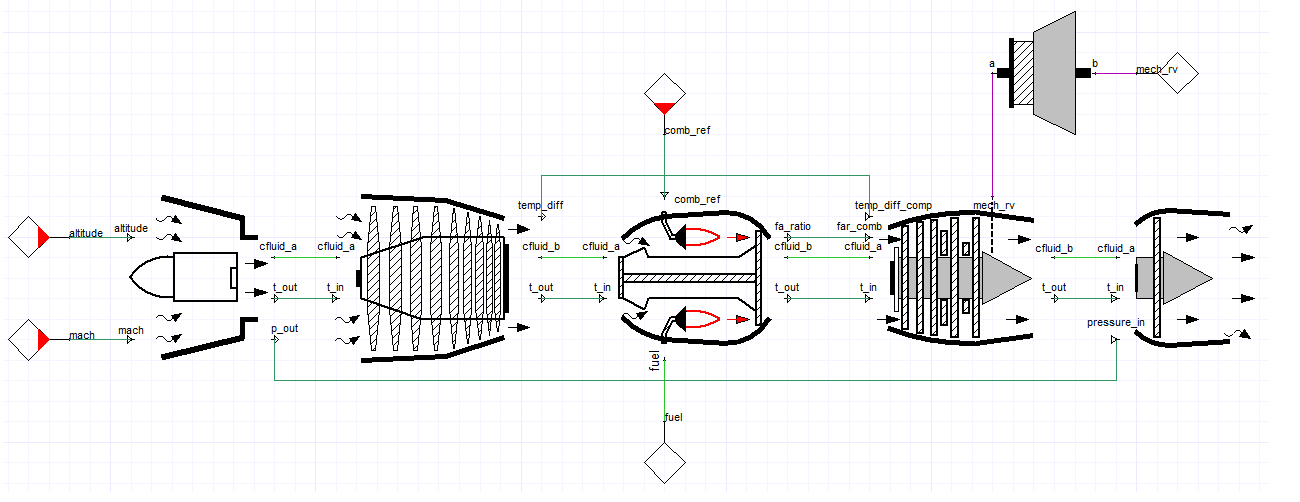

## Inlet
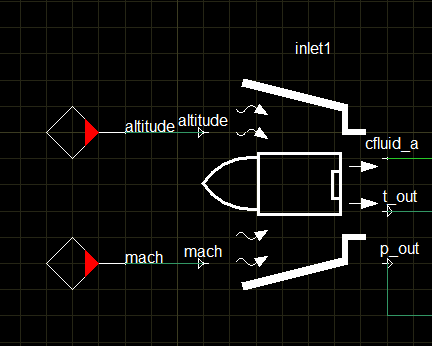

### Inlet VHDL-AMS 코드



- 전체 코드(엔티티 + 아키텍처): [vhdl/inlet.vhd](vhdl/inlet.vhd)

### Inlet Architecture 해설 (터보프롭 관점)

#### 1) 모델 목적
이 Inlet 블록은 비행 고도(`altitude`)와 마하수(`mach`)를 입력으로 받아 코어 유입 온도(`t_out`)과 압력(`p_out`)을 계산합니다. 터보프롭에서는 이 값이 이후 압축기 작동점과 최종 프로펠러 가용축출력에 직접 영향을 줍니다.

#### 2) 핵심 상수와 의미
- `a1, a2`: 대류권(약 11 km 이하) 표준대기 근사 계수
- `t_amb_c, a3, a4, a5`: 성층권 초기 구간(11~25 km) 대기 근사 계수
- `gamma`: 비열비, 등엔트로피 정체량 계산에 사용

#### 3) 물리식 해석
고도 구간별 정적 대기 상태(`t_amb_t`, `p_amb_t`)를 계산한 뒤, 마하수 기반 정체량으로 변환합니다.

$$
T_t = T \left(1 + \frac{\gamma-1}{2} M^2\right)
$$

$$
P_t = P \left(1 + \frac{\gamma-1}{2} M^2\right)^{\frac{\gamma}{\gamma-1}}
$$

그리고 `eta_cal(mach)`를 통해 고마하에서의 inlet pressure recovery를 반영합니다.

#### 4) 터보프롭 시스템 관점
- 터보프롭 순항영역(중저마하)에서도 inlet 손실은 연료소모율(SFC)과 축출력 여유를 바꿉니다.
- `p_out` 저하는 압축기 후단 압력비/효율에 연쇄 영향을 주고, 결과적으로 프로펠러 축동력 감소로 이어집니다.

#### 5) 교육/고장주입 포인트
- 흡입계 오염/결빙 모사: `eta_cal` 계수(`a6`, `a7`) 조정
- 센서 오프셋 모사: `altitude`, `mach` 바이어스 주입
- 성능 저하 민감도: 동일 스로틀에서 `p_out`, `power`, `fa_ratio` 동시 관찰

## 압축기
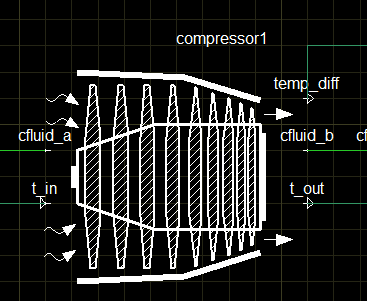

### Compressor 아키텍처 코드 위치

- 전체 코드(엔티티 + 아키텍처): [vhdl/compressor.vhd](vhdl/compressor.vhd)

### Compressor Architecture 해설

#### 1) 모델 목적
압축기 입구 온도/압력과 압력비(`pressureRatio`)를 기반으로 corrected mass flow를 계산하고, compressor-map 형태의 효율(`eta_comp`)을 반영해 출구 상태와 소요 동력(`power`)을 계산합니다.

#### 2) 핵심 상수
- `gamma = 1.4`, `r = 287.04`
- `cp = \gamma R/(\gamma-1)`

#### 3) 핵심 식
함수 `temp_pre_calculation(...)`이 압축기 열역학을 직접 구현합니다.

$$
T_{out}=T_{in}\left[1+\frac{1}{\eta_c}\left(\pi_c^{(\gamma-1)/\gamma}-1\right)\right]
$$

$$
P_{out}=\pi_c P_{in}
$$

동력은 질량유량 기반 엔탈피 증가로 계산합니다.

$$
\dot W_c = \dot m\, C_p\, (T_{out}-T_{in})
$$

#### 4) 모델링 관점
- 함수 반환형 `real_vector2`로 온도/압력을 동시 계산
- `pressure == p_in - p_out_temp`로 네트워크 압력강하 표현
- `assert`로 파라미터 범위(`pressureRatio>0`, `0\le eta_comp\le 1`) 검증

#### 5) 교육/고장주입 포인트
- 압축기 오염/마모: `eta_comp` 저하
- 서지 여유 감소 시나리오: `pressureRatio` 운전점 변동
- 동력 소모 이상 탐지: `power` 시계열 기반 CBM 지표 구성

### Map-based Compressor (New Model)

#### Map-based Compressor VHDL-AMS 코드

| 버전 | 파일 | 설명 |
|------|------|------|
| v1 (generic 기반) | [vhdl/compressor_map_based.vhd](vhdl/compressor_map_based.vhd) | `pressureRatio_nom`, `eta_comp_peak`를 generic으로 고정 |
| **v2 (LUT 포트 기반)** | [vhdl/compressor_map_based_v2.vhd](vhdl/compressor_map_based_v2.vhd) | `eta_in`, `pr_in`을 외부 LUT 포트로 수신 ← **현재 사용 버전** |

#### Map-based Compressor 설명 (v2 — LUT 포트 기반)

**v2** ([compressor_map_based_v2.vhd](vhdl/compressor_map_based_v2.vhd))는 효율과 압력비를 generic 상수가 아닌 **외부 포트**로 수신합니다.

- `eta_in` : 등엔트로피 효율 [-] — 외부 LUT에서 주입  
- `pr_in`  : 압력비 [-] — 외부 LUT에서 주입  
- `t_in`   : 입구 온도 [K] — 기존 배선 유지  
- 내부에서 `eta_safe`로 smooth-clamp 처리 (하한 0.50) — 발산 방지

**LUT 설계 방침 (algebraic-loop 금지)**

- LUT 입력은 `mass_rot1.omega` [rad/s]만 사용  
  - `mflow` 사용 시 mflow → eta → ΔP → mflow 순환 → 발산  
- 설계점: $\omega_{des}=2800$ rad/s, $\eta_{des}=0.85$, $PR_{des}=8.0$

**맵 데이터 (기본값)**

| $\omega$ [rad/s] | 1000 | 1500 | 2000 | 2500 | 2800 | 3000 | 3500 |
|---|---|---|---|---|---|---|---|
| $\eta$ [-]       | 0.72 | 0.76 | 0.80 | 0.83 | 0.85 | 0.84 | 0.80 |
| $PR$ [-]         | 5.0  | 5.8  | 6.5  | 7.3  | 8.0  | 8.2  | 8.0  |

#### Basic vs. Map-based Compressor v2 변수 비교

| 구분 | 항목 | `compressor.vhd` (Basic) | `compressor_map_based_v2.vhd` (v2) | 비고 |
|------|------|:---:|:---:|------|
| **Generic** | 압력비 / 효율 | ✅ `pressureRatio`(8.0), `eta_comp`(0.85) | ✗ **없음** | v2에서 전부 포트로 이동 |
| **Port 입력** | `t_in` | ✅ | ✅ | 입구 온도 [K] |
| | `eta_in` | ✗ | ✅ **추가** | 등엔트로피 효율 [-] — LUT 수신 |
| | `pr_in` | ✗ | ✅ **추가** | 압력비 [-] — LUT 수신 |
| | 회전속도 직접 입력 | ✗ | ✗ | v2도 omega는 외부 LUT가 수신 |
| **Port 출력** | `temp_diff`, `power`, `t_out` | ✅ | ✅ | 인터페이스 동일 → 직접 교체 가능 |
| **유체 터미널** | `cfluid_a`, `cfluid_b` | ✅ | ✅ | 호환 |
| **Internal qty** | `pressure`, `mflow`, `p_in`, `p_out_temp`, `t_out_temp` | ✅ | ✅ | 동일 |
| | `eta_safe` (smooth-clamp) | ✗ | ✅ | 효율 하한 0.50 보장 |
| **효율 계산** | 방식 | 고정 `eta_comp` | LUT→`eta_in`→`eta_safe`→열역학식 | 운전점 의존 |
| **압력비** | 방식 | 고정 `pressureRatio` | LUT→`pr_in`→열역학식 | 운전점 의존 |
| **algebraic loop** | 위험 | 없음 | 없음 (omega 기반 LUT로 회피) | ⚠️ `mflow` 사용 금지 |

## VHDL-AMS 구현을 위한 Map-based Compressor 이론 정리 (본 모델 기준)

이 섹션은 현재 노트북의 map-based compressor 구성을 기준으로,
VHDL-AMS 모델 작성에 직접 필요한 수식과 이론만 정리한 것입니다.

### 1) 상태 변수와 맵 좌표

map-based compressor는 보통 다음 2개 좌표를 기준으로 동작합니다.

- 보정 회전속도: $N_{corr}$
- 보조 좌표: $\beta \in [0,1]$
  - $\beta=0$: choke 경계
  - $\beta=1$: surge 경계

맵 출력은 일반적으로 아래 3개 스칼라 필드입니다.

- 압력비: $\pi = p_{out}/p_{in}$
- 보정 질량유량: $\dot m_{corr}$
- 등엔트로피 효율: $\eta_{isen}$

즉 다음의 2변수 함수 집합으로 모델링합니다.

$$
\pi = \pi(N_{corr},\beta),\quad
\dot m_{corr}=\dot m_{corr}(N_{corr},\beta),\quad
\eta_{isen}=\eta_{isen}(N_{corr},\beta)
$$

### 2) 보정 유량/속도 정의

입구 조건 변화 영향을 표준화하기 위해 보정량을 사용합니다.

$$
\dot m_{corr}=\dot m\left(\frac{\sqrt{T_{in}/T_{ref}}}{p_{in}/p_{ref}}\right)
$$

$$
N_{corr}=N\sqrt{\frac{T_{in}}{T_{ref}}}
$$

여기서 $T_{ref}, p_{ref}$는 기준 조건입니다.

역변환은 다음과 같습니다.

$$
\dot m = \dot m_{corr}\left(\frac{p_{in}/p_{ref}}{\sqrt{T_{in}/T_{ref}}}\right)
$$

### 3) 맵 보간

격자점 $(N_i,\beta_j)$의 테이블 값을 연속 운전점 $(N_{corr},\beta)$로 확장하려면 보간이 필요합니다.

- 정규 격자: bilinear interpolation
- 비정규 포인트: 삼각분할 기반 선형 보간(또는 nearest 보완)

각 출력 $f\in\{\pi,\dot m_{corr},\eta_{isen}\}$에 대해
$$
f^* = \mathcal{I}_f(N_{corr},\beta)
$$
로 계산합니다.

### 4) 경계(choke/surge) 처리

맵 외부에서 수치 발산을 막기 위한 기본 규칙입니다.

- surge 측($\beta>1$): $\beta\leftarrow 1$ 클램프 또는 물리 외삽
- choke 측($\beta<0$): $\beta\leftarrow 0$ 클램프 또는 물리 외삽
- 효율은 경계에서 하한 제한

안정성 우선 구현에서는 다음을 많이 사용합니다.

$$
\beta_{eff}=\min(1,\max(0,\beta))
$$

### 5) 압축기 열역학 관계

압력비가 주어졌을 때 이상(등엔트로피) 출구온도는
$$
\frac{T_{out,s}}{T_{in}} = \pi^{(\gamma-1)/\gamma}
$$

등엔트로피 엔탈피 상승:
$$
\Delta h_{isen}=c_p\,(T_{out,s}-T_{in})
$$

실제 엔탈피 상승:
$$
\Delta h = \frac{\Delta h_{isen}}{\eta_{isen}}
$$

실제 출구온도:
$$
T_{out}=T_{in}+\frac{\Delta h}{c_p}
$$

### 6) 축동력/토크

유체에 전달되는 동력:
$$
P_{fluid}=\dot m\,\Delta h
$$

기계효율 $\eta_m$ 포함 축동력:
$$
P_{shaft}=\frac{P_{fluid}}{\eta_m}
$$

요구 토크:
$$
\tau=\frac{P_{shaft}}{\omega}
$$

영속도 근처 안정화를 위해 보통
$$
\tau=\frac{P_{shaft}}{\max(|\omega|,\omega_{min})}\,\mathrm{sign}(\omega)
$$
형태를 사용합니다.

### 7) 보존식

질량 보존:
$$
\dot m_{in}+\dot m_{out}=0
$$

에너지 보존(열손실 무시):
$$
\dot m\,(h_{out}-h_{in}) = P_{fluid}
$$

열손실 고려 시:
$$
\dot m\,(h_{out}-h_{in}) = P_{fluid}-\dot Q_{loss}
$$

### 8) VHDL-AMS 방정식화 절차

1. 입력($p_{in},T_{in},N$)으로 $N_{corr}$ 계산
2. $\beta$ 결정(상태변수/수렴변수)
3. 맵 보간으로 $\pi,\dot m_{corr},\eta_{isen}$ 계산
4. 역보정으로 실제 $\dot m$ 계산
5. 열역학식으로 $T_{out},\Delta h$ 계산
6. $P_{shaft},\tau$ 계산
7. 포트 연속식/에너지식을 동시에 만족하도록 연립

### 9) 수치 안정화 권장값

- $\eta_{isen}\ge \eta_{min}>0$
- 압력비 하한: $\pi\ge 1$ (압축기 모드)
- 영유량 근처 완화함수 도입
- 맵 경계 미분 불연속 완화(스무딩)

예시:
$$
\beta_{sm}=\frac{1}{2}\left[1+\tanh\left(\frac{\beta-\beta_0}{\epsilon}\right)\right]
$$

### 10) 현재 노트북 데이터와 연결

- speed line 데이터: $N_{corr}$별 곡선 형상
- surge/choke 데이터: $\beta$ 경계 조건
- 효율 데이터: $\eta_{isen}(N_{corr},\beta)$ 구성

즉 현재 노트북의 map 데이터는 VHDL-AMS에서
"보간기 + 열역학식 + 보존식"을 결합한 compressor 컴포넌트의 핵심 파라미터 세트입니다.

## 연소기
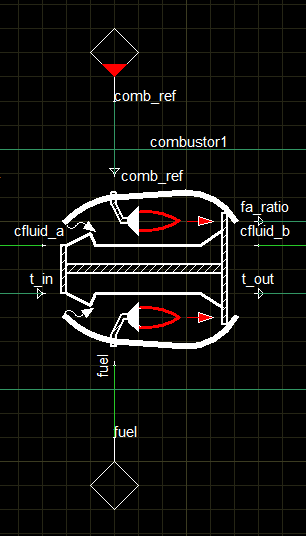

### Combustor 아키텍처 코드 위치

- 전체 코드(엔티티 + 아키텍처): [vhdl/combustor.vhd](vhdl/combustor.vhd)

### Combustor Architecture 해설

#### 1) 모델 목적
이 연소기 모델은 목표 출구온도(`comb_ref`)를 만족하도록 필요한 연료-공기비(`fuel_air_ratio`)를 역산하는 구조입니다.

#### 2) 핵심 상수
- `gamma = 1.31`: 고온 연소가스 비열비
- `cp = \gamma R/(\gamma-1)`
- `fuel_calorific = 42075500` J/kg: 연료 저위발열량(LHV)

#### 3) 핵심 방정식
출구온도는 제어 목표값으로 직접 지정됩니다.

$$
T_{out} = T_{ref}
$$

압력은 압력회복률(또는 손실효율) `eff`로 반영됩니다.

$$
P_{out} = \eta_{p,comb} P_{in}
$$

연료-공기비는 에너지 보존식에서 유도됩니다.

$$
\dot m_a C_p T_{in}+\dot m_f LHV=(\dot m_a+\dot m_f)C_p T_{out}
$$

$$
f=\frac{\frac{T_{out}}{T_{in}}-1}{\frac{LHV}{C_p T_{in}}-\frac{T_{out}}{T_{in}}}
$$

그리고 연료유량은 다음과 같습니다.

$$
\dot m_f = f\,\dot m_a
$$

#### 4) 모델링 관점
- 전방향(forward) 연소 모델이 아니라 목표 온도 기반 역산(reverse-calculation) 모델
- 제어기와 결합 시 TIT 추종 시뮬레이션에 매우 유리
- `pressure across mflow`로 유체 포트와 일관된 결합

#### 5) 교육/고장주입 포인트
- 연소기 열화: `eff`를 점진 저하시켜 압력손실 증가 재현
- 연료 품질 변화: `fuel_calorific` 편차 주입
- 제어기 성능 비교: 동일 `comb_ref`에서 요구 `mflow_fuel` 변화량 분석

## Turbine
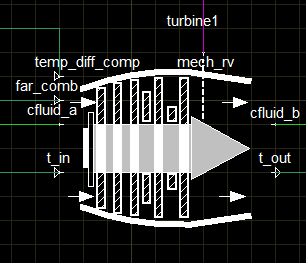

### Turbine 아키텍처 코드 위치

- 전체 코드(엔티티 + 아키텍처): [vhdl/turbine.vhd](vhdl/turbine.vhd)

### Turbine Architecture 해설 (터보프롭 관점)

#### 1) 모델 목적
터빈은 압축기 요구 일(`temp_diff_comp`)과 연소기 FAR(`far_comb`)를 받아 출구 상태와 축동력(`power`)을 계산합니다. 터보프롭 관점에서는 이 축동력이 감속기/프로펠러에 전달되는 원천 에너지입니다.

#### 2) 핵심 식
코드의 `temp_pre_calculation(...)`은 다음 해석을 가집니다.

- 터빈 출구온도(코드 변수 `temperature1`):
$$
T_{out} = T_{in} + \Delta T_{comp}\,\eta_m\,(1+f)
$$

- 효율을 고려한 압력비 관계:
$$
P_{out}=P_{in}\left(1-\frac{1-T_{out}/T_{in}}{\eta_t}\right)^{\gamma/(\gamma-1)}
$$

- 터빈 축동력:
$$
\dot W_t = -\dot m C_p (T_{in}-T_{out})
$$

#### 3) 터보프롭 해석 포인트
- 이 모델은 코어 축동력 중심 표현이며, 실기체의 자유터빈(power turbine) 단계는 등가 효율/부하로 흡수해 해석할 수 있습니다.
- 프로펠러 부하가 증가하면 샤프트 토크 균형점이 이동하고, 같은 연료유량에서도 `omega`와 `power`의 과도응답이 달라집니다.
- `omega * tau == power` 관계를 통해 열유체 에너지가 회전기계 에너지로 변환됩니다.

#### 4) 교육/고장주입 포인트
- 터빈 열화: `eta_t` 감소
- 기계 손실 증가: `eta_m` 감소
- 프로펠러 부하 교란(외생): 샤프트 측 부하토크 변동 입력
- 진단 특징: `power` 리플, `omega` 정착시간, `t_out` 상승 경향

### Map-based Turbine (New Model)

### Map-based Turbine VHDL-AMS 코드

- 모델 파일 열기: [vhdl/map_based_turbine.vhd](vhdl/map_based_turbine.vhd)
- 노트북에서는 코드 본문을 제거하고 외부 파일로 분리했습니다.

### Map-based Turbine 설명

- 맵 기반 터빈은 보정 속도/유량/효율 테이블을 기반으로 운전점과 축출력을 계산합니다.
- 기본 터빈 모델 대비 오프디자인(부분부하/경계영역) 해석에 적합합니다.
- 구현 파일: [vhdl/map_based_turbine.vhd](vhdl/map_based_turbine.vhd)

## Map-based 모델 시각화 (Python)

In [1]:
import re
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.io import loadmat

from plot_style import (
    MATLAB_CHOKE,
    MATLAB_EFF_SCALE,
    MATLAB_SPEED,
    MATLAB_SURGE,
    apply_compressor_map_style,
    register_project_templates,
)


# Register shared template once per kernel session.
register_project_templates(set_default=True)


# MATLAB example data files
MATLAB_EXAMPLE_ROOT = r"C:\Users\user\Documents\MATLAB\Examples\R2025a\simscapefluids\CompressorMapExample"
SPEED_MAT_PATH = MATLAB_EXAMPLE_ROOT + r"\CompressorMapSpeedLines.mat"
EFF_MAT_PATH = MATLAB_EXAMPLE_ROOT + r"\CompressorMapEfficiencyData.mat"


def _load_mat(path):
    """Load MATLAB .mat file and keep only user variables."""
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    return {k: v for k, v in data.items() if not k.startswith("__")}


def _to_2col_array(x):
    arr = np.asarray(x, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 2)
    return arr


# 1) Load speed-line data: Line1000, Line1500, ...
speed_data = _load_mat(SPEED_MAT_PATH)
line_items = []
for key, val in speed_data.items():
    m = re.fullmatch(r"Line(\d+)", key)
    if m is None:
        continue
    rpm = int(m.group(1))
    arr = _to_2col_array(val)
    if arr.shape[1] < 2:
        continue
    line_items.append((rpm, arr))

if not line_items:
    raise RuntimeError("No LineXXXX variables found in CompressorMapSpeedLines.mat")

line_items.sort(key=lambda t: t[0])
omega_TLU = np.array([rpm for rpm, _ in line_items], dtype=float)
mdot_TLU = np.vstack([arr[:, 0] for _, arr in line_items])
pr_TLU = np.vstack([arr[:, 1] for _, arr in line_items])
beta_TLU = np.linspace(0.0, 1.0, mdot_TLU.shape[1])


# 2) Load efficiency contour data: Eff80, Eff82, ...
eff_data = _load_mat(EFF_MAT_PATH)
eff_blocks = []
for key, val in eff_data.items():
    m = re.fullmatch(r"Eff(\d+)", key)
    if m is None:
        continue
    eta = int(m.group(1)) / 100.0
    arr = _to_2col_array(val)
    if arr.shape[1] < 2:
        continue
    eta_col = np.full((arr.shape[0], 1), eta, dtype=float)
    eff_blocks.append(np.hstack([arr[:, :2], eta_col]))

if not eff_blocks:
    raise RuntimeError("No EffXX variables found in CompressorMapEfficiencyData.mat")

Efficiency = np.vstack(eff_blocks)


# 3) Interpolate efficiency onto speed-line grid (MATLAB scatteredInterpolant equivalent)
pts = Efficiency[:, :2]
vals = Efficiency[:, 2]
lin_interp = LinearNDInterpolator(pts, vals, fill_value=np.nan)
eta_TLU = lin_interp(mdot_TLU, pr_TLU)

# Fill extrapolation holes with nearest-neighbor interpolation
if np.isnan(eta_TLU).any():
    nn_interp = NearestNDInterpolator(pts, vals)
    eta_TLU_nn = nn_interp(mdot_TLU, pr_TLU)
    eta_TLU = np.where(np.isnan(eta_TLU), eta_TLU_nn, eta_TLU)


# 4) Surge / Choke extraction
# MATLAB example guideline: points are sampled from choke -> surge along each speed line
choke_mdot = mdot_TLU[:, 0]
choke_pr = pr_TLU[:, 0]
surge_mdot = mdot_TLU[:, -1]
surge_pr = pr_TLU[:, -1]


# 5) Plot compressor map
fig = go.Figure()

# Efficiency contours (line-only style, MATLAB-like)
fig.add_trace(
    go.Contour(
        x=mdot_TLU.ravel(),
        y=pr_TLU.ravel(),
        z=eta_TLU.ravel(),
        contours=dict(start=0.80, end=0.90, size=0.02, showlabels=True, labelfont=dict(size=12, color="black")),
        colorscale=MATLAB_EFF_SCALE,
        contours_coloring="lines",
        line_width=1,
        showscale=False,
        name="Isentropic Efficiency",
    )
)

# Constant speed lines
for i, rpm in enumerate(omega_TLU.astype(int)):
    fig.add_trace(
        go.Scatter(
            x=mdot_TLU[i, :],
            y=pr_TLU[i, :],
            mode="lines",
            line=dict(width=2, color=MATLAB_SPEED),
            name="Constant Speed Lines (rpm)" if i == 0 else None,
            showlegend=(i == 0),
        )
    )

# Choke line (beta=0)
fig.add_trace(
    go.Scatter(
        x=choke_mdot,
        y=choke_pr,
        mode="lines",
        line=dict(color=MATLAB_CHOKE, width=2),
        name="Choke Line",
    )
)

# Surge line (beta=1)
fig.add_trace(
    go.Scatter(
        x=surge_mdot,
        y=surge_pr,
        mode="lines",
        line=dict(color=MATLAB_SURGE, width=2),
        name="Surge Line",
    )
)

apply_compressor_map_style(fig)
fig.show()


print("Loaded speed lines:", [int(x) for x in omega_TLU])
print("TLU shape (M,N):", mdot_TLU.shape)
print("Efficiency range:", float(np.nanmin(eta_TLU)), "to", float(np.nanmax(eta_TLU)))

Loaded speed lines: [1000, 1500, 2000, 2500, 3000, 3500]
TLU shape (M,N): (6, 7)
Efficiency range: 0.8 to 0.9


--------------------------------------------------------------------------
--                                                                      --
-- Copyright (c) 2014 by ANSYS Inc.  All rights reserved.             	--
--                                                                      --
-- This source file may be used and distributed without restriction     --
-- provided that this copyright statement is not removed from the file  --
-- and that any derivative work contains this copyright notice.         --
--                                                                      --
-- Model name: shaft     		                      			       	--
-- Library: Aircraft Electrical VHDLAMS                                	--
-- 																		--
-- -----------------------------------------------------------------------
--                 Warranty                                             --
-- -----------------------------------------------------------------------
-- ANSYS Incorporation makes no warranty of any kind with regard to the --
-- use of this Software, either expressed or implied, including, but not--
-- limited to the fitness for a particular purpose.						--
-- 																		--
-- -----------------------------------------------------------------------
-- Modification History :                                               --
-- -----------------------------------------------------------------------
-- Version No:|Auth:| Mod.Date:| Changes Made:                          --
-- -----------------------------------------------------------------------
library ieee;
use ieee.math_real.all;
use ieee.mechanical_systems.all;

entity shaft is
	generic (
                inertia      	: real  := 1.0;                     -- shaft inertia [kg * m^2].
                omega0          : real  := 0.0
            );   
    port    ( 
               terminal a,b     : rotational_velocity
            );

end entity shaft;

architecture behav of shaft is
    quantity omega across tau through a to b;   
begin
    if domain = quiescent_domain use
        omega == omega0;
    else
        omega'dot == tau / inertia;
    end use;
end architecture behav;

## Shaft


### Shaft Architecture 해설

#### 1) 모델 목적
샤프트는 터빈/압축기 사이 회전 동역학을 담당하며, 토크 불균형이 각속도 변화로 누적되는 관성 요소입니다.

#### 2) 방정식
정상 초기화 구간(`quiescent_domain`)에서는 초기속도를 강제합니다.

$$
\omega = \omega_0
$$

일반 동작 구간에서는 뉴턴 회전 운동 방정식을 풉니다.

$$
\dot\omega = \frac{\tau}{J}
$$

여기서 $J$는 `inertia`입니다.

#### 3) 시스템 모델링 관점
- 연속시간 적분 상태를 갖는 핵심 동적 블록
- 터빈 출력 토크와 압축기 부하 토크의 차이가 속도 과도응답을 결정
- 시동/가속/부하변동 시나리오에서 엔진 스풀 거동의 중심축 역할

#### 4) 교육/고장주입 포인트
- 베어링/축 마찰 증가를 등가 손실 토크로 추가 가능
- `inertia` 변경으로 스풀 응답 지연/민감도 비교
- 고장진단에서 `omega` 과도응답(오버슈트/정착시간) 특징량 추출

## 브레이턴 사이클 통합 해설 (터보프롭 강화판)

### 1) 터보프롭 에너지 변환 체인
Inlet → Compressor → Combustor → Turbine → Shaft → (Gearbox/Propeller 등가부하)로 해석합니다.

- 코어 유량의 열에너지를 최종적으로 추진축 출력으로 바꾸는 구조
- 터보제트/터보팬 대비, 추진력의 대부분이 제트 분사보다 프로펠러 축출력에서 생성

### 2) 스테이션 기반 통합 해석 틀
교육 시 다음 스테이션 개념으로 설명하면 이해가 빠릅니다.
- Inlet 출구: $(T_{t2}, P_{t2})$
- Compressor 출구: $(T_{t3}, P_{t3})$
- Combustor 출구(TIT): $(T_{t4}, P_{t4})$
- Turbine 출구: $(T_{t5}, P_{t5})$

코드 대응은 다음과 같습니다.
- `t_out`, `p_out` (Inlet/Compressor/Combustor/Turbine 각 블록)
- `fa_ratio` (연료-공기비)
- `power`, `omega` (축 에너지 상태)

### 3) 컴포넌트 연성 핵심
- Inlet 손실 증가 → Compressor 유효 작동점 저하
- Compressor 일 증가 → Combustor 요구 연료 증가
- Combustor TIT 목표 증가 → Turbine 가용 일 증가(동시에 열부하 증가)
- Turbine/shaft 동역학 → 프로펠러 부하와 토크 균형으로 속도 결정

즉, 단일 블록 이상이 아니라 압력, 온도, 질량유량, 축동력이 서로 닫힌 루프로 결합됩니다.

### 4) 터보프롭 성능 지표 연결
모델 출력으로 다음 지표를 직접 구성할 수 있습니다.

$$
\dot W_{prop,avail} \approx \eta_{gb}\,\dot W_{shaft}
$$

$$
SFC_{shaft} = \frac{\dot m_f}{\dot W_{prop,avail}}
$$

- `mflow_fuel`과 `power`를 결합하면 축기준 연료소모율 추정 가능
- 고도/마하/부하 변화에 대한 출력 민감도를 맵 형태로 학습 가능

### 5) Fault Injection 통합 시나리오 (CBM+)
- 시나리오 A: Inlet 열화(`eta_cal` 저하)
- 시나리오 B: Compressor 효율 저하(`eta_comp` 감소)
- 시나리오 C: Combustor 압력손실 증가(`eff` 감소)
- 시나리오 D: Turbine/기계 열화(`eta_t`, `eta_m` 감소)
- 시나리오 E: Shaft/prop 부하 이상(부하토크 교란)

각 시나리오에서 `fa_ratio`, `power`, `omega`, `t_out`, `p_out`를 동기 샘플링하면 고장 분류 및 잔여수명 추정용 데이터셋을 체계적으로 구축할 수 있습니다.

### 6) 실습 운영 팁 (9시간 과정)
- 1단계: 정상기준선 모델 검증(정상상태 + 과도응답)
- 2단계: 단일 고장 주입 민감도 분석
- 3단계: 복합 열화 주입 및 식별 난이도 비교
- 4단계: 특징량 엔지니어링(정착시간, 리플, 기울기, 상관계수)
- 5단계: 진단/예지 모델 학습 데이터셋 완성

# TwinBuilder API


In [2]:
import os
import tempfile
import time
import ansys.aedt.core
AEDT_VERSION = "2026.1"
NUM_CORES = 8
NG_MODE = False  # Open AEDT UI when it is launched.
app=ansys.aedt.core

In [2]:
# designName='Aircraft Electrical System'
# subSheet1Name='GT Engine'
# subSheet2Name='IDG'

tb=app.TwinBuilder(
    project='GT_Engine',design='Gas Turbine Engine',non_graphical=NG_MODE,new_desktop=False,version="2026.1")
# tb=app.TwinBuilder(
#     project='Aircraft Electrical System',non_graphical=NG_MODE,new_desktop=False,version="2026.1")

PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Initializing Desktop session.
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: Found active AEDT gRPC session on port 50051.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 50051.
PyAEDT INFO: Project GT_Engine set to active.
PyAEDT INFO: Active Design set to 0;Gas Turbine Engine
PyAEDT INFO: AEDT objects correctly read


In [3]:
tb.close_desktop()

PyAEDT INFO: Desktop has been released and closed.


True

In [ ]:
# Result post-processing helper: time-domain plot + operating line on T-s / P-v
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


_TIME_UNIT_TO_SEC = {
    "s": 1.0,
    "sec": 1.0,
    "ms": 1.0e-3,
    "us": 1.0e-6,
    "ns": 1.0e-9,
    "ps": 1.0e-12,
    "fs": 1.0e-15,
}


def _pick_setup_name(tb_obj):
    for attr_name in ["existing_analysis_sweeps", "setup_sweeps_names", "analysis_sweeps"]:
        if hasattr(tb_obj, attr_name):
            try:
                values = list(getattr(tb_obj, attr_name))
                if values:
                    return values[0]
            except Exception:
                pass
    return None


def _parse_time_value_to_seconds(value):
    if value is None:
        return None

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip()
    if not text:
        return None

    m = re.match(r"^([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*([a-zA-Zuµμ]*)$", text)
    if not m:
        return None

    mag = float(m.group(1))
    unit = m.group(2).strip().lower()
    unit = unit.replace("µ", "u").replace("μ", "u")

    if unit == "":
        return mag
    if unit in _TIME_UNIT_TO_SEC:
        return mag * _TIME_UNIT_TO_SEC[unit]
    return None


def _get_time_unit_from_solution_data(sol_data):
    candidates = []

    for attr in ["primary_sweep_unit", "sweep_unit", "time_unit"]:
        try:
            if hasattr(sol_data, attr):
                v = getattr(sol_data, attr)
                if v:
                    candidates.append(str(v).strip())
        except Exception:
            pass

    for attr in ["units_sweeps", "units", "intrinsics"]:
        try:
            if not hasattr(sol_data, attr):
                continue
            v = getattr(sol_data, attr)
            if isinstance(v, dict):
                for k in ["Time", "time", "TIME"]:
                    if k in v and v[k]:
                        candidates.append(str(v[k]).strip())
        except Exception:
            pass

    for cand in candidates:
        key = cand.lower().replace(" ", "")
        if key in _TIME_UNIT_TO_SEC:
            return key

    return None


def _extract_xy_from_solution_data(sol_data, expr):
    if sol_data is None:
        return None, None

    t = None
    y = None

    for tk in ["Time", "time", "TIME"]:
        try:
            if hasattr(sol_data, "intrinsics") and tk in sol_data.intrinsics:
                t = np.asarray(sol_data.intrinsics[tk], dtype=float)
                break
        except Exception:
            pass

    if t is None:
        try:
            if hasattr(sol_data, "primary_sweep_values"):
                t = np.asarray(sol_data.primary_sweep_values, dtype=float)
        except Exception:
            t = None

    # If AEDT exposes explicit time unit metadata, convert immediately to seconds.
    time_unit = _get_time_unit_from_solution_data(sol_data)
    if t is not None and time_unit in _TIME_UNIT_TO_SEC:
        t = t * _TIME_UNIT_TO_SEC[time_unit]

    try:
        if hasattr(sol_data, "data_real"):
            y = np.asarray(sol_data.data_real(expr), dtype=float)
    except Exception:
        y = None

    if t is None or y is None or len(t) == 0 or len(y) == 0:
        return None, None
    return t, y


def _get_signal_from_post(tb_obj, expr, setup_name=None):
    post = getattr(tb_obj, "post", None)
    if post is None or not hasattr(post, "get_solution_data"):
        return None, None

    attempts = [
        {"expressions": [expr], "domain": "Time", "setup_sweep_name": setup_name},
        {"expressions": [expr], "domain": "Time"},
        {"expressions": expr, "domain": "Time", "setup_sweep_name": setup_name},
        {"expressions": expr, "domain": "Time"},
    ]

    for kwargs in attempts:
        try:
            sol_data = post.get_solution_data(**kwargs)
            t, y = _extract_xy_from_solution_data(sol_data, expr)
            if t is not None and y is not None:
                return t, y
        except Exception:
            continue

    return None, None


def _infer_time_scale_from_simparam(df_merged):
    if df_merged is None or df_merged.empty or "time" not in df_merged.columns:
        return 1.0, None

    cols = list(df_merged.columns)
    sim_cols = [c for c in cols if "simparam" in c.lower()]
    if not sim_cols:
        return 1.0, None

    raw_time = pd.to_numeric(df_merged["time"], errors="coerce").to_numpy(dtype=float)
    raw_time = raw_time[np.isfinite(raw_time)]
    if len(raw_time) < 2:
        return 1.0, None

    dt_raw = np.median(np.diff(np.unique(raw_time)))
    t_end_raw = float(np.nanmax(raw_time))

    step_cols = [c for c in sim_cols if any(k in c.lower() for k in ["step", "tstep", "dt", "sample"])]
    end_cols = [c for c in sim_cols if any(k in c.lower() for k in ["tend", "tstop", "stop", "end"])]

    for c in step_cols:
        try:
            val = _parse_time_value_to_seconds(df_merged[c].dropna().iloc[0])
            if val is not None and val > 0 and dt_raw > 0:
                return float(val / dt_raw), f"{c}={val}s"
        except Exception:
            pass

    for c in end_cols:
        try:
            val = _parse_time_value_to_seconds(df_merged[c].dropna().iloc[0])
            if val is not None and val > 0 and t_end_raw > 0:
                return float(val / t_end_raw), f"{c}={val}s"
        except Exception:
            pass

    return 1.0, None


def collect_time_domain_results(tb_obj, signal_map, setup_name=None):
    if setup_name is None:
        setup_name = _pick_setup_name(tb_obj)

    merged = None
    found = []
    missing = []

    for alias, expr in signal_map.items():
        t, y = _get_signal_from_post(tb_obj, expr, setup_name=setup_name)
        if t is None:
            missing.append((alias, expr))
            continue

        found.append((alias, expr))
        df_sig = pd.DataFrame({"time": t, alias: y}).dropna()
        if merged is None:
            merged = df_sig
        else:
            merged = merged.merge(df_sig, on="time", how="outer")

    if merged is not None:
        merged = merged.sort_values("time").drop_duplicates(subset=["time"]).reset_index(drop=True)

        scale, src = _infer_time_scale_from_simparam(merged)
        if np.isfinite(scale) and scale > 0 and not np.isclose(scale, 1.0):
            merged["time"] = merged["time"] * scale
            print(f"[time-unit] applied simparam scaling: x{scale:.12g} (source: {src})")
        else:
            dt = np.median(np.diff(np.unique(merged["time"].to_numpy(dtype=float)))) if len(merged) > 1 else np.nan
            print(f"[time-unit] no simparam scaling applied. dt={dt:.6g} s")

    return merged, found, missing


def plot_time_domain(df_time):
    fig = go.Figure()
    for col in [c for c in df_time.columns if c != "time"]:
        fig.add_trace(go.Scatter(x=df_time["time"], y=df_time[col], mode="lines", name=col))
    fig.update_layout(
        template="plotly_white",
        title="TwinBuilder Result - Time Domain",
        xaxis_title="Time [s]",
        yaxis_title="Signal Value",
        height=420,
    )
    fig.show()

In [ ]:
def plot_operating_line_ts_pv(
    df_time,
    cp=1005.0,
    gamma=1.4,
    time_index=0,
    time_indices=None,
    pressure_lines_mpa=(0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10),
):
    required = ["T1", "T2", "T3", "T4", "P1", "P2", "P3", "P4"]
    missing_cols = [c for c in required if c not in df_time.columns]
    if missing_cols:
        print("Cannot draw T-s/P-v operating lines. Missing columns:", missing_cols)
        return

    R = cp * (gamma - 1.0) / gamma
    eps = 1e-12

    for c in required:
        df_time[c] = pd.to_numeric(df_time[c], errors="coerce")

    df = df_time.dropna(subset=required).copy()
    if df.empty:
        print("No valid rows for T-s/P-v plotting after NaN cleanup.")
        return

    n = len(df)
    if n == 0:
        print("No rows to plot.")
        return

    if time_indices is None:
        idx_list = [int(np.clip(time_index, 0, n - 1))]
    else:
        if isinstance(time_indices, (int, np.integer)):
            time_indices = [int(time_indices)]
        idx_list = [int(np.clip(i, 0, n - 1)) for i in time_indices]
        idx_list = sorted(set(idx_list))
        if not idx_list:
            idx_list = [int(np.clip(time_index, 0, n - 1))]

    T1 = np.clip(df["T1"].to_numpy(dtype=float), eps, None)
    T2 = np.clip(df["T2"].to_numpy(dtype=float), eps, None)
    T3 = np.clip(df["T3"].to_numpy(dtype=float), eps, None)
    T4 = np.clip(df["T4"].to_numpy(dtype=float), eps, None)

    P1 = np.clip(df["P1"].to_numpy(dtype=float), eps, None)
    P2 = np.clip(df["P2"].to_numpy(dtype=float), eps, None)
    P3 = np.clip(df["P3"].to_numpy(dtype=float), eps, None)
    P4 = np.clip(df["P4"].to_numpy(dtype=float), eps, None)

    # Relative entropy from state 1, then convert to kJ/(kg*K) for MATLAB-like axis.
    s1 = np.zeros_like(T1)
    s2 = s1 + cp * np.log(T2 / T1) - R * np.log(P2 / P1)
    s3 = s2 + cp * np.log(T3 / T2) - R * np.log(P3 / P2)
    s4 = s3 + cp * np.log(T4 / T3) - R * np.log(P4 / P3)

    v1 = R * T1 / P1
    v2 = R * T2 / P2
    v3 = R * T3 / P3
    v4 = R * T4 / P4

    markers = ["circle", "square", "diamond", "triangle-up", "triangle-down"]
    palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]

    fig = make_subplots(rows=1, cols=2, subplot_titles=("Temperature-Entropy Diagram", "Pressure-Volume Diagram"))

    # MATLAB-like pressure lines on T-s diagram.
    t_min = max(273.15, float(np.nanmin([T1.min(), T2.min(), T3.min(), T4.min()])) * 0.9)
    t_max = max(2000.0, float(np.nanmax([T1.max(), T2.max(), T3.max(), T4.max()])) * 1.05)
    T_grid = np.logspace(np.log10(t_min), np.log10(t_max), 120)
    T_ref = 300.0
    P_ref = 1.0e5

    for i, p_mpa in enumerate(pressure_lines_mpa):
        p_pa = float(p_mpa) * 1.0e6
        s_line = (cp * np.log(T_grid / T_ref) - R * np.log(p_pa / P_ref)) / 1000.0
        showlegend = i == 0
        fig.add_trace(
            go.Scatter(
                x=s_line,
                y=T_grid,
                mode="lines",
                line=dict(color="#d99000", width=1),
                name="Pressure Lines (MPa)" if showlegend else None,
                showlegend=showlegend,
            ),
            row=1,
            col=1,
        )
        label_k = int(0.68 * (len(T_grid) - 1))
        fig.add_annotation(
            x=float(s_line[label_k]),
            y=float(T_grid[label_k]),
            text=f"{p_mpa:g}",
            showarrow=False,
            textangle=-35,
            font=dict(size=10, color="#333333"),
            xref="x1",
            yref="y1",
        )

    for i, idx in enumerate(idx_list):
        color = palette[i % len(palette)]
        t_val = float(df["time"].iloc[idx]) if "time" in df.columns else float(idx)

        s_points_kj = np.array([s1[idx], s2[idx], s3[idx], s4[idx], s1[idx]], dtype=float) / 1000.0
        T_points = np.array([T1[idx], T2[idx], T3[idx], T4[idx], T1[idx]], dtype=float)

        v_points = np.array([v1[idx], v2[idx], v3[idx], v4[idx], v1[idx]], dtype=float)
        p_points = np.array([P1[idx], P2[idx], P3[idx], P4[idx], P1[idx]], dtype=float)

        fig.add_trace(
            go.Scatter(
                x=s_points_kj,
                y=T_points,
                mode="lines",
                line=dict(color=color, width=3),
                name=f"Cycle @ t={t_val:.3g}s",
            ),
            row=1,
            col=1,
        )

        fig.add_trace(
            go.Scatter(
                x=v_points,
                y=p_points,
                mode="lines",
                line=dict(width=3, color=color),
                name=f"Cycle @ t={t_val:.3g}s",
                showlegend=False,
            ),
            row=1,
            col=2,
        )

        if i == len(idx_list) - 1:
            for k in range(5):
                fig.add_trace(
                    go.Scatter(
                        x=[s_points_kj[k]],
                        y=[T_points[k]],
                        mode="markers",
                        marker=dict(size=9, symbol=markers[k], color="#1f77b4"),
                        name=f"Cycle Point {k+1}",
                    ),
                    row=1,
                    col=1,
                )

    fig.update_xaxes(title_text="Specific Entropy (kJ/(kg*K))", row=1, col=1)
    fig.update_yaxes(title_text="Temperature (K)", row=1, col=1)
    fig.update_xaxes(title_text="Specific Volume (m^3/kg)", row=1, col=2)
    fig.update_yaxes(title_text="Pressure (Pa)", row=1, col=2)

    if len(idx_list) == 1:
        title_text = f"Temperature-Entropy Diagram (t = {float(df['time'].iloc[idx_list[0]]):.3g} s)"
    else:
        title_text = f"Temperature-Entropy Diagram Overlay ({len(idx_list)} time snapshots)"

    fig.update_layout(
        template="plotly_white",
        height=540,
        title=title_text,
        legend=dict(x=0.01, y=0.98),
    )
    fig.show()

## parsing from TwinBuilder post API 

In [ ]:
# Sequential parsing from TwinBuilder post API (cell 50 style) -> fallback probe
import re

def _as_list(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple, set)):
        return list(value)
    return [value]

def _read_attr_or_call(obj, name):
    if not hasattr(obj, name):
        return []
    v = getattr(obj, name)
    try:
        return _as_list(v()) if callable(v) else _as_list(v)
    except Exception:
        return []

def _parse_exprs_from_post_api(tb_obj):
    post = tb_obj.post
    solutions = _read_attr_or_call(post, "available_report_solutions")
    categories = _read_attr_or_call(post, "available_quantities_categories")
    report_types = ["Standard", "Transient", None]

    print("solutions:", solutions)
    print("categories:", categories if categories else "(none)")

    exprs = []
    fn = getattr(post, "available_report_quantities", None)
    if not callable(fn):
        return [], solutions

    for sol in (solutions or [None]):
        for cat in (categories or [None]):
            for rpt in report_types:
                kwargs = {}
                if sol is not None:
                    kwargs["solution"] = sol
                if cat is not None:
                    kwargs["quantities_category"] = cat
                if rpt is not None:
                    kwargs["report_category"] = rpt
                try:
                    got = fn(**kwargs)
                    if got:
                        exprs.extend(list(got))
                        print("api ok:", kwargs, "->", len(got))
                except Exception:
                    continue

    return sorted(set(exprs)), solutions

def _component_labels(tb_obj):
    labels = []
    try:
        tb_obj.modeler.schematic.refresh_all_ids()
        for comp in tb_obj.modeler.schematic.components.values():
            label = getattr(comp, "instance_name", None) or getattr(comp, "name", None)
            if label:
                label = str(label)
                if "@" in label:
                    label = label.split("@", 1)[0]
                if label not in labels:
                    labels.append(label)
    except Exception:
        pass
    return labels

def _fallback_probe_exprs(tb_obj, setup_name):
    labels = _component_labels(tb_obj)
    # Keep fallback small and deterministic
    fields = ["t_out", "p_out", "omega", "t_in", "p_in", "power", "torque", "fa_ratio"]
    valid = []
    for lb in labels:
        for fd in fields:
            expr = f"{lb}.{fd}"
            t, y = _get_signal_from_post(tb_obj, expr, setup_name=setup_name)
            if t is not None and y is not None:
                valid.append(expr)
    return sorted(set(valid))

post_exprs, post_solutions = _parse_exprs_from_post_api(tb)
setup_name = post_solutions[0] if post_solutions else "TR"

if post_exprs:
    print("\nUsing expressions from post API:", len(post_exprs))
    raw_exprs = post_exprs
else:
    print("\nPost API expression listing not available. Start fallback probing.")
    raw_exprs = _fallback_probe_exprs(tb, setup_name=setup_name)
    print("Fallback valid expressions:", len(raw_exprs))

for e in raw_exprs[:150]:
    print(" -", e)

# Use raw quantity names directly (no alias mapping)
SIGNAL_MAP = {e: e for e in raw_exprs}

result_df, found_signals, missing_signals = collect_time_domain_results(tb, SIGNAL_MAP, setup_name=setup_name)
print("\nFound:", len(found_signals), "| Missing:", len(missing_signals))

if result_df is None or result_df.empty:
    print("No time-domain result fetched. Check setup/expressions.")
else:
    display(result_df.head())
    plot_time_domain(result_df)

In [ ]:
# Feasibility check for T-s / P-v operating points from current 45 expressions
required_raw = {
    "T1": "inlet1.t_out",
    "T2": "compressor1.t_out",
    "T3": "combustor1.t_out",
    "T4": "turbine1.t_out",
    "P1": "inlet1.p_out",
    "P2": "compressor1.p_out",
    "P3": "combustor1.p_out",
    "P4": "turbine1.p_out",
}

if "result_df" not in globals() or result_df is None or result_df.empty:
    print("result_df is empty. Run cell 50 first.")
else:
    cols = set(result_df.columns)
    present = {k: v for k, v in required_raw.items() if v in cols}
    missing = {k: v for k, v in required_raw.items() if v not in cols}

    print("Present required signals:")
    for k, v in present.items():
        print(" -", k, v)

    print("\nMissing required signals:")
    for k, v in missing.items():
        print(" -", k, v)

    feasible = len(missing) == 0
    print("\nCan draw operating points on T-s/P-v with current 45 expressions:", feasible)

    p_like = [c for c in sorted(cols) if (".p_" in c.lower() or "pressure" in c.lower())]
    print("\nAvailable pressure-like columns:")
    for c in p_like:
        print(" -", c)

In [ ]:
# Inverse-pressure reconstruction for T-s / P-v plotting from current expressions
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

if "result_df" not in globals() or result_df is None or result_df.empty:
    raise RuntimeError("result_df is empty. Run cell 50 first.")

# Use model/generic values. Update these if your TwinBuilder model uses different settings.
PR = 8.0
eff_comb = 0.95
eta_t = 0.87
gamma_t = 1.31
eps = 1e-12

df = result_df.copy()

T1 = pd.to_numeric(df.get("inlet1.t_out"), errors="coerce")
T2 = pd.to_numeric(df.get("compressor1.t_out"), errors="coerce")
T3 = pd.to_numeric(df.get("combustor1.t_out"), errors="coerce")
T4 = pd.to_numeric(df.get("turbine1.t_out"), errors="coerce")
P1 = pd.to_numeric(df.get("inlet1.p_out"), errors="coerce")

if any(x is None for x in [T1, T2, T3, T4, P1]):
    raise RuntimeError("Required base signals are missing: inlet1/compressor1/combustor1/turbine1 temperatures and inlet1.p_out")

# Reconstruct pressures from component equations
P2 = PR * P1
P3 = eff_comb * P2
ratio = np.clip(T4 / np.clip(T3, eps, None), eps, None)
base = 1.0 - (1.0 - ratio) / eta_t
base = np.clip(base, eps, None)
P4 = P3 * np.power(base, gamma_t / (gamma_t - 1.0))

df_ts = pd.DataFrame({
    "time": df["time"],
    "T1": T1,
    "T2": T2,
    "T3": T3,
    "T4": T4,
    "P1": P1,
    "P2": P2,
    "P3": P3,
    "P4": P4,
}).dropna()

print("rows for T-s/P-v:", len(df_ts))
display(df_ts.head())

# Redraw a single cycle curve when the slider moves.
if len(df_ts) == 0:
    raise RuntimeError("df_ts is empty after reconstruction.")

idx_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df_ts) - 1,
    step=1,
    description="time idx",
    continuous_update=False,
)

out_plot = widgets.Output()


def _draw_at_index(idx):
    with out_plot:
        out_plot.clear_output(wait=True)
        plot_operating_line_ts_pv(df_ts, time_index=int(idx))


def _on_slider_change(change):
    if change.get("name") == "value":
        _draw_at_index(change["new"])


idx_slider.observe(_on_slider_change, names="value")
display(idx_slider, out_plot)
_draw_at_index(idx_slider.value)


# GIF export function: animate one closed cycle curve over time on T-s plane.
def export_ts_cycle_gif(
    df_time,
    out_path="ts_cycle.gif",
    cp=1005.0,
    gamma=1.4,
    pressure_lines_mpa=(0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10),
    n_frames=80,
    fps=12,
):
    try:
        import matplotlib.pyplot as plt
        from matplotlib.animation import FuncAnimation, PillowWriter
    except Exception as e:
        raise RuntimeError("matplotlib + pillow is required for GIF export.") from e

    required = ["T1", "T2", "T3", "T4", "P1", "P2", "P3", "P4"]
    missing_cols = [c for c in required if c not in df_time.columns]
    if missing_cols:
        raise RuntimeError(f"Missing columns for GIF export: {missing_cols}")

    df_local = df_time.copy()
    for c in required:
        df_local[c] = pd.to_numeric(df_local[c], errors="coerce")
    df_local = df_local.dropna(subset=required).reset_index(drop=True)

    if df_local.empty:
        raise RuntimeError("No valid rows for GIF export.")

    R = cp * (gamma - 1.0) / gamma
    eps_local = 1e-12

    T1v = np.clip(df_local["T1"].to_numpy(dtype=float), eps_local, None)
    T2v = np.clip(df_local["T2"].to_numpy(dtype=float), eps_local, None)
    T3v = np.clip(df_local["T3"].to_numpy(dtype=float), eps_local, None)
    T4v = np.clip(df_local["T4"].to_numpy(dtype=float), eps_local, None)

    P1v = np.clip(df_local["P1"].to_numpy(dtype=float), eps_local, None)
    P2v = np.clip(df_local["P2"].to_numpy(dtype=float), eps_local, None)
    P3v = np.clip(df_local["P3"].to_numpy(dtype=float), eps_local, None)
    P4v = np.clip(df_local["P4"].to_numpy(dtype=float), eps_local, None)

    s1 = np.zeros_like(T1v)
    s2 = s1 + cp * np.log(T2v / T1v) - R * np.log(P2v / P1v)
    s3 = s2 + cp * np.log(T3v / T2v) - R * np.log(P3v / P2v)
    s4 = s3 + cp * np.log(T4v / T3v) - R * np.log(P4v / P3v)

    sample_idx = np.linspace(0, len(df_local) - 1, max(2, int(n_frames))).astype(int)

    fig, ax = plt.subplots(figsize=(7.2, 5.2), dpi=120)

    t_min = max(273.15, float(np.nanmin([T1v.min(), T2v.min(), T3v.min(), T4v.min()])) * 0.9)
    t_max = max(2000.0, float(np.nanmax([T1v.max(), T2v.max(), T3v.max(), T4v.max()])) * 1.05)
    T_grid = np.logspace(np.log10(t_min), np.log10(t_max), 120)
    T_ref = 300.0
    P_ref = 1.0e5

    for p_mpa in pressure_lines_mpa:
        p_pa = float(p_mpa) * 1.0e6
        s_line = (cp * np.log(T_grid / T_ref) - R * np.log(p_pa / P_ref)) / 1000.0
        ax.plot(s_line, T_grid, color="#d99000", linewidth=0.8)
        label_k = int(0.68 * (len(T_grid) - 1))
        ax.text(s_line[label_k], T_grid[label_k], f"{p_mpa:g}", fontsize=8, rotation=-35, color="#333333")

    ax.plot([], [], color="#d99000", linewidth=1.0, label="Pressure Lines (MPa)")

    cycle_line, = ax.plot([], [], color="#6a9f2d", linewidth=2.2, label="Cycle Curve")
    markers = ["o", "s", "D", "^", "v"]
    point_handles = []
    for i, mk in enumerate(markers, start=1):
        h, = ax.plot([], [], mk, markersize=6, color="#1f77b4", label=f"Cycle Point {i}")
        point_handles.append(h)

    ax.set_xlabel("Specific Entropy (kJ/(kg*K))")
    ax.set_ylabel("Temperature (K)")
    ax.legend(loc="upper left", fontsize=8)

    def _update(frame_i):
        idx = int(sample_idx[frame_i])
        s_pts = np.array([s1[idx], s2[idx], s3[idx], s4[idx], s1[idx]], dtype=float) / 1000.0
        t_pts = np.array([T1v[idx], T2v[idx], T3v[idx], T4v[idx], T1v[idx]], dtype=float)

        cycle_line.set_data(s_pts, t_pts)
        for j in range(5):
            point_handles[j].set_data([s_pts[j]], [t_pts[j]])

        t_val = float(df_local["time"].iloc[idx]) if "time" in df_local.columns else float(idx)
        ax.set_title(f"Temperature-Entropy Diagram (t = {t_val:.3g} s)")

        x_pad = 0.12
        y_pad = 0.06
        ax.set_xlim(float(np.nanmin(s_pts)) - x_pad, float(np.nanmax(s_pts)) + x_pad)
        ax.set_ylim(float(min(t_min, np.nanmin(t_pts) * (1 - y_pad))), float(max(t_max, np.nanmax(t_pts) * (1 + y_pad))))

        return [cycle_line, *point_handles]

    anim = FuncAnimation(fig, _update, frames=len(sample_idx), interval=max(1, int(1000 / max(1, fps))), blit=False)

    out_file = Path(out_path)
    out_file.parent.mkdir(parents=True, exist_ok=True)
    anim.save(str(out_file), writer=PillowWriter(fps=fps))
    plt.close(fig)

    print("GIF saved:", str(out_file))
    return str(out_file)


# Quick UI for GIF export from current reconstructed dataframe.
gif_path = widgets.Text(value="ts_cycle.gif", description="gif path")
gif_frames = widgets.IntSlider(value=80, min=20, max=240, step=10, description="frames", continuous_update=False)
gif_fps = widgets.IntSlider(value=12, min=4, max=30, step=1, description="fps", continuous_update=False)
gif_button = widgets.Button(description="GIF 저장", button_style="success")
gif_out = widgets.Output()


def _on_make_gif(_):
    with gif_out:
        gif_out.clear_output(wait=True)
        export_ts_cycle_gif(df_ts, out_path=gif_path.value, n_frames=gif_frames.value, fps=gif_fps.value)


display(widgets.HBox([gif_path, gif_frames, gif_fps, gif_button]), gif_out)

In [ ]:
gif_button.on_click(_on_make_gif)


## Twin-Builder 모델링 & Simulation 4 Map-based Compressor

In [ ]:
newDesignName='Gas Turbine Engine_Map'
tb.duplicate_design(newDesignName)

In [ ]:
tb=app.TwinBuilder(
    project='GT_Engine',design='Gas Turbine Engine_Map',non_graphical=NG_MODE,new_desktop=False,version="2026.1")

## flatten aedt data

In [ ]:
# Diagnostic: list component names in GT_Engine-related design context
def _resolve_local_design(tb_obj, requested_name=None):
    if not requested_name:
        return tb_obj.design_name
    if requested_name in tb_obj.design_list:
        return requested_name

    req = str(requested_name).strip().lower()
    for d in tb_obj.design_list:
        if str(d).strip().lower() == req:
            return d
    for d in tb_obj.design_list:
        if req in str(d).lower():
            return d
    return None


requested = globals().get("subSheet1Name", None)
candidate_order = [
    requested,
    "GT Engine",
    "Gas Turbine Engine",
    tb.design_name,
]

target_design = None
for cand in candidate_order:
    resolved = _resolve_local_design(tb, cand)
    if resolved is not None:
        target_design = resolved
        break

active_design = tb.design_name
if target_design is None:
    print("Could not resolve GT_Engine target design.")
    print("Available designs:", tb.design_list)
else:
    switched = target_design != active_design
    if switched:
        tb.set_active_design(target_design)

    try:
        tb.modeler.schematic.refresh_all_ids()
        components = list(tb.modeler.schematic.components.values())
        all_names = [getattr(c, "name", None) for c in components]
        all_instances = [getattr(c, "instance_name", None) for c in components]

        print("Resolved target design:", target_design)
        print("Component count:", len(all_names))
        print("First 50 component names:")
        for n in [x for x in all_names if x][:50]:
            print(" -", n)

        print("\nFirst 50 instance names (non-empty):")
        for n in [x for x in all_instances if x][:50]:
            print(" -", n)

        gt_like = [
            c for c in all_names
            if isinstance(c, str) and any(tok in c.lower() for tok in ["compressor", "turbine", "combustor", "inlet", "shaft", "gt"])
        ]
        print("\nGT-like component names (first 30):")
        for n in gt_like[:30]:
            print(" -", n)
    finally:
        if switched:
            tb.set_active_design(active_design)

### 

In [ ]:
# Try extraction on likely candidates in GT_Engine project context
target_design = globals().get("subSheet1Name", None) or "GT Engine"

if "get_vhdlams_source_from_component" not in globals():
    print("Run the flatten/extraction definition cell first (cell 56).")
else:
    for query in ["compressor", "turbine", "combustor", "GT Engine"]:
        print("\n=== Query:", query, "===")
        try:
            result = get_vhdlams_source_from_component(tb, target_design, query, by="name")
            if "error" in result:
                print("Error:", result["error"])
                if "available_component_names" in result:
                    print("Candidates sample:", result["available_component_names"][:10])
                continue

            print("Resolved design:", result.get("resolved_design"))
            print("Component:", result.get("component_name"))
            print("Model:", result.get("model_name"))
            print("Blocks:", len(result.get("source_blocks", [])))

            if result.get("source_blocks"):
                print(result["source_blocks"][0][:1200])
            else:
                print("No VHDL-AMS block extracted for this query.")
        except Exception as e:
            print("Failed:", e)

In [ ]:
print("Active design:", tb.design_name)
print("Design list:", tb.design_list)


try:
    sub_designs = tb.odesign.GetSubDesigns()
    print("GetSubDesigns:", sub_designs)
except Exception as e:
    print("GetSubDesigns failed:", e)

In [ ]:
subs = tb.odesign.GetSubDesigns()
for i, sd in enumerate(subs):
    print(f"\nSubDesign[{i}] type:", type(sd))
    print("repr:", sd)
    for m in ["GetName", "GetDesignName", "GetPropNames", "GetProperties", "GetPropertyValue", "GetObjPath"]:
        ok = hasattr(sd, m)
        print(f"  has {m}:", ok)
        if ok and m in ["GetName", "GetDesignName", "GetObjPath"]:
            try:
                print(f"    {m}() ->", getattr(sd, m)())
            except Exception as e:
                print(f"    {m}() failed:", e)

In [ ]:
# Check whether the design object supports entering subdesign context
design_methods = [m for m in dir(tb.odesign) if "Design" in m or "design" in m]
for m in sorted(design_methods):
    if any(k in m for k in ["Push", "Pop", "Active", "Sub", "GetDesign"]):
        print(m)


print("has PushDesign:", hasattr(tb.odesign, "PushDesign"))
print("has PopDesign:", hasattr(tb.odesign, "PopDesign"))

In [ ]:
# NOTE: PushDesign is exposed in API but may fail for gRPC sessions.
# Keep this as a safe probe without stopping notebook execution.
try:
    tb.odesign.PushDesign("GT Engine")
    try:
        tb.modeler.schematic.refresh_all_ids()
        names_gt = [c.name for c in tb.modeler.schematic.components.values()]
        print("GT Engine component count:", len(names_gt))
        for n in names_gt[:40]:
            print(" -", n)
    finally:
        tb.odesign.PopDesign()
except Exception as e:
    print("PushDesign probe failed:", e)
    print("This usually means subdesign navigation is not supported in current API/session mode.")

In [ ]:
subs = tb.odesign.GetSubDesigns()
sd = subs[0]
candidates = [
    sd.GetDesignName(),
    sd.GetName(),
    sd.GetObjPath(),
    "GT Engine",
    "SubSheet1",
    "U1",
]


for arg in candidates:
    try:
        tb.odesign.PushDesign(arg)
        print("PushDesign success with:", arg)
        tb.odesign.PopDesign()
    except Exception as e:
        print("PushDesign failed with:", arg, "|", e)

In [ ]:
from collections.abc import Mapping


def _iter_components(tb_comp_obj):
    """Return a flat list of CircuitComponent objects."""
    if hasattr(tb_comp_obj, "components") and isinstance(tb_comp_obj.components, dict):
        return list(tb_comp_obj.components.values())
    if isinstance(tb_comp_obj, Mapping):
        return list(tb_comp_obj.values())
    raise TypeError("tb_comp_obj must be a components dict or modeler.schematic object")


def _safe_to_dict(obj):
    """Convert pyaedt parameter objects to a plain dict."""
    if not obj:
        return {}
    if isinstance(obj, dict):
        return dict(obj)
    out = {}
    try:
        for k in obj.keys():
            out[str(k)] = obj[k]
    except Exception:
        pass
    return out


def get_component_by_name(tb_comp_obj, text_to_find, exact=False):
    """Find a component by name/composed_name/instance_name."""
    for comp in _iter_components(tb_comp_obj):
        candidates = [
            getattr(comp, "name", None),
            getattr(comp, "composed_name", None),
            getattr(comp, "instance_name", None),
        ]
        if exact:
            if any(c == text_to_find for c in candidates if c):
                return comp
        else:
            if any(text_to_find in c for c in candidates if c):
                return comp
    return None


def get_component_by_instance_name(tb_comp_obj, instance_name):
    """Find a component by exact InstanceName."""
    for comp in _iter_components(tb_comp_obj):
        if getattr(comp, "instance_name", None) == instance_name:
            return comp
    return None


def get_component_properties(comp):
    """Return component properties grouped by tabs."""
    return {
        "parameters": _safe_to_dict(getattr(comp, "parameters", {})),
        "component_info": _safe_to_dict(getattr(comp, "component_info", {})),
    }


def get_subsheet_component_report(tb, subsheet_name):
    """
    Return all components and properties from a TwinBuilder subsheet.

    Parameters
    ----------
    tb : TwinBuilder
    subsheet_name : str
        Design name of the subsheet.
    """
    if subsheet_name not in tb.design_list:
        raise ValueError(f"'{subsheet_name}' is not in tb.design_list: {tb.design_list}")

    active_design = tb.design_name
    switched = active_design != subsheet_name
    if switched:
        tb.set_active_design(subsheet_name)

    try:
        tb.modeler.schematic.refresh_all_ids()
        report = []
        for comp in tb.modeler.schematic.components.values():
            report.append(
                {
                    "name": getattr(comp, "name", None),
                    "instance_name": getattr(comp, "instance_name", None),
                    "composed_name": getattr(comp, "composed_name", None),
                    "page": getattr(comp, "page", None),
                    "properties": get_component_properties(comp),
                }
            )
        return report
    finally:
        if switched:
            tb.set_active_design(active_design)


def list_subsheet_component_names(tb, subsheet_name):
    """Convenience helper: only return component names in a subsheet."""
    report = get_subsheet_component_report(tb, subsheet_name)
    return [r["name"] for r in report]

In [ ]:
import re


def _flatten_aedt_data(node, out_list, depth=0, max_depth=30):
    """Flatten nested AEDT payloads into string nodes for regex extraction."""
    if depth > max_depth:
        return

    if isinstance(node, str):
        out_list.append(node)
        return

    if isinstance(node, bytes):
        try:
            out_list.append(node.decode("utf-8", errors="ignore"))
        except Exception:
            out_list.append(str(node))
        return

    if isinstance(node, (int, float, bool)) or node is None:
        out_list.append(str(node))
        return

    if isinstance(node, dict):
        for k, v in node.items():
            _flatten_aedt_data(k, out_list, depth=depth + 1, max_depth=max_depth)
            _flatten_aedt_data(v, out_list, depth=depth + 1, max_depth=max_depth)
        return

    if isinstance(node, (list, tuple, set)):
        for item in node:
            _flatten_aedt_data(item, out_list, depth=depth + 1, max_depth=max_depth)
        return

    out_list.append(str(node))


def _extract_vhdlams_blocks_from_text_nodes(text_nodes):
    merged = "\n".join([t for t in text_nodes if isinstance(t, str)])

    patterns = [
        r"(?is)(library\s+ieee\s*;[\s\S]*?end\s+entity\s+[a-zA-Z0-9_]+\s*;)",
        r"(?is)(architecture\s+[a-zA-Z0-9_]+\s+of\s+[a-zA-Z0-9_]+\s+is[\s\S]*?end\s+architecture\s+[a-zA-Z0-9_]+\s*;)",
        r"(?is)(entity\s+[a-zA-Z0-9_]+\s+is[\s\S]*?end\s+entity\s+[a-zA-Z0-9_]+\s*;)",
    ]

    blocks = []
    for p in patterns:
        for m in re.finditer(p, merged):
            b = m.group(1).strip()
            if b and b not in blocks:
                blocks.append(b)
    return blocks


def _resolve_design_name(tb, requested_name=None):
    if not requested_name:
        return tb.design_name
    if requested_name in tb.design_list:
        return requested_name

    req = str(requested_name).strip().lower()
    for d in tb.design_list:
        if str(d).strip().lower() == req:
            return d
    for d in tb.design_list:
        if req in str(d).lower():
            return d
    return None


def _guess_gt_design_name(tb, requested_name=None):
    candidates = [
        requested_name,
        globals().get("subSheet1Name", None),
        "GT Engine",
        "Gas Turbine Engine",
        tb.design_name,
    ]
    for cand in candidates:
        resolved = _resolve_design_name(tb, cand)
        if resolved is not None:
            return resolved
    return None


def _enter_design_context(tb, requested_name=None):
    """Enter design context via set_active_design; fallback to PushDesign if needed."""
    active_design = tb.design_name
    resolved = _resolve_design_name(tb, requested_name)
    switched = False
    pushed = False
    push_error = None

    if resolved is not None and resolved != active_design:
        tb.set_active_design(resolved)
        switched = True
    elif resolved is None and requested_name and hasattr(tb.odesign, "PushDesign"):
        try:
            tb.odesign.PushDesign(requested_name)
            resolved = requested_name
            pushed = True
        except Exception as e:
            push_error = str(e)

    def _cleanup():
        if pushed and hasattr(tb.odesign, "PopDesign"):
            try:
                tb.odesign.PopDesign()
            except Exception:
                pass
        if switched:
            try:
                tb.set_active_design(active_design)
            except Exception:
                pass

    return resolved, _cleanup, {
        "active_design": active_design,
        "switched": switched,
        "pushed": pushed,
        "push_error": push_error,
    }


def _auto_pick_component(tb):
    components = list(tb.modeler.schematic.components.values())
    preferred = ["compressor", "turbine", "combustor", "inlet", "shaft", "gt engine"]

    for token in preferred:
        for comp in components:
            name = str(getattr(comp, "name", "")).lower()
            inst = str(getattr(comp, "instance_name", "")).lower()
            if token in name or token in inst:
                return comp

    return components[0] if components else None


def get_vhdlams_source_from_component(tb, subsheet_name, comp_query=None, by="name"):
    """Extract internal model text (if exposed by AEDT API) from GT_Engine-oriented context."""
    requested_design = _guess_gt_design_name(tb, subsheet_name)
    resolved_design, cleanup, ctx = _enter_design_context(tb, requested_design)

    if resolved_design is None:
        return {
            "error": f"Design '{subsheet_name}' not found and PushDesign fallback failed",
            "available_designs": tb.design_list,
            "context": ctx,
            "source_blocks": [],
        }

    try:
        tb.modeler.schematic.refresh_all_ids()

        if comp_query:
            if by == "instance_name":
                comp = get_component_by_instance_name(tb.modeler.schematic, comp_query)
            else:
                comp = get_component_by_name(tb.modeler.schematic, comp_query, exact=False)
        else:
            comp = _auto_pick_component(tb)

        if comp is None:
            candidates = [c.name for c in tb.modeler.schematic.components.values()]
            return {
                "error": f"Component not found: {comp_query}",
                "resolved_design": resolved_design,
                "available_component_names": candidates[:80],
                "source_blocks": [],
            }

        model_name = getattr(comp, "model_name", None)
        raw_payloads = {}

        def _collect_payload(key_name, manager_name, manager_obj):
            try:
                payload = manager_obj.GetData(key_name)
                try:
                    raw_payloads[manager_name] = list(payload)
                except Exception:
                    raw_payloads[manager_name] = payload
                return True
            except Exception as e:
                raw_payloads[f"{manager_name}_error"] = str(e)
                return False

        if model_name:
            _collect_payload(model_name, "omodel_manager", tb.modeler.schematic.omodel_manager)
            _collect_payload(model_name, "o_simmodel_manager", tb.modeler.schematic.o_simmodel_manager)

        comp_keys = []
        comp_name = getattr(comp, "name", None)
        if comp_name:
            comp_keys.append(comp_name.split("@", 1)[1] if "@" in comp_name else comp_name)
            comp_keys.append(comp_name)

        composed_name = getattr(comp, "composed_name", None)
        if composed_name:
            comp_keys.append(composed_name)

        if model_name:
            comp_keys.append(model_name)

        seen = set()
        for key in [k for k in comp_keys if k]:
            if key in seen:
                continue
            seen.add(key)
            ok = _collect_payload(key, f"ocomponent_manager::{key}", tb.modeler.schematic.ocomponent_manager)
            if ok:
                break

        text_nodes = []
        _flatten_aedt_data(raw_payloads, text_nodes)
        source_blocks = _extract_vhdlams_blocks_from_text_nodes(text_nodes)

        return {
            "resolved_design": resolved_design,
            "component_name": getattr(comp, "name", None),
            "instance_name": getattr(comp, "instance_name", None),
            "composed_name": getattr(comp, "composed_name", None),
            "model_name": model_name,
            "source_blocks": source_blocks,
            "raw_payloads": raw_payloads,
            "flatten_node_count": len(text_nodes),
        }
    finally:
        cleanup()


def save_first_vhdlams_block(result_dict, out_path):
    blocks = result_dict.get("source_blocks", [])
    if not blocks:
        raise RuntimeError("No VHDL-AMS source block found in API payload.")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(blocks[0])
    return out_path


# Example usage (safe): choose a GT_Engine-related component
example_design = globals().get("subSheet1Name", None) or "GT Engine"
example_query = "compressor"
res = get_vhdlams_source_from_component(tb, example_design, example_query, by="name")
print("Result keys:", list(res.keys()))
if "error" in res:
    print("Error:", res["error"])
    if "available_component_names" in res:
        print("Candidate names:", res["available_component_names"][:20])

elif res["source_blocks"]:
    print("Resolved design:", res.get("resolved_design"))
    print("Component:", res.get("component_name"))
    print("Found blocks:", len(res["source_blocks"]))
    print(res["source_blocks"][0][:2500])
else:
    print("No source block found for", example_query)
    print("Flattened nodes:", res.get("flatten_node_count"))
    print("(Model may be protected/compiled or not stored as plain text in API payload.)")

In [ ]:
# Quick diagnostic for GT_Engine map-based model stability
import numpy as np

print('Active design:', tb.design_name)
print('Available designs:', tb.design_list)

# Resolve likely GT design
cands = ['GT_Engine', 'GT Engine', 'Gas Turbine Engine', 'Gas Turbine Engine_Map', tb.design_name]
resolved = None
for c in cands:
    for d in tb.design_list:
        if str(c).lower() in str(d).lower():
            resolved = d
            break
    if resolved:
        break
print('Resolved target design:', resolved)

# Component snapshot
try:
    tb.modeler.schematic.refresh_all_ids()
    comps = list(tb.modeler.schematic.components.values())
    names = [getattr(c, 'name', '') for c in comps]
    insts = [getattr(c, 'instance_name', '') for c in comps]
    print('Component count:', len(comps))
    print('GT-like instances:', [i for i in insts if isinstance(i, str) and any(k in i.lower() for k in ['compressor', 'turbine', 'combustor', 'shaft', 'mass', 'nozzle'])][:20])
except Exception as e:
    print('Component scan failed:', e)

if 'result_df' not in globals() or result_df is None or len(result_df) == 0:
    print('result_df is empty. Run the result collection cell first.')
else:
    df = result_df.copy()
    cols = df.columns.tolist()
    print('result_df rows:', len(df))

    key_patterns = {
        'omega': ['omega', 'mass_rot', 'shaft'],
        'comp_power': ['compressor', 'power'],
        'turb_power': ['turbine', 'power'],
        'mflow': ['mflow', 'mdot'],
        'pressure': ['p_in', 'p_out', 'pressure'],
        'temperature': ['t_in', 't_out', 'temp']
    }

    def pick_cols(patterns):
        picked = []
        for c in cols:
            cl = c.lower()
            if all(p in cl for p in patterns):
                picked.append(c)
        return picked

    summary_cols = []
    for grp, pats in key_patterns.items():
        for c in cols:
            cl = c.lower()
            if any(p in cl for p in pats):
                summary_cols.append(c)
    summary_cols = sorted(set(summary_cols))

    print('\nKey signal ranges (first 25):')
    for c in summary_cols[:25]:
        s = pd.to_numeric(df[c], errors='coerce')
        if s.notna().any():
            print(f" - {c}: min={s.min():.4e}, max={s.max():.4e}, last={s.iloc[-1]:.4e}")

    # Direct sanity checks
    omega_cols = [c for c in cols if 'omega' in c.lower()]
    if omega_cols:
        print('\nOmega sanity:')
        for c in omega_cols:
            s = pd.to_numeric(df[c], errors='coerce')
            if s.notna().any():
                max_abs = np.nanmax(np.abs(s.values))
                print(f" - {c}: max|x|={max_abs:.4e}")
                if max_abs > 1e6:
                    print('   [WARN] Very high omega detected (>1e6). Check turbine power-torque coupling and shaft damping/inertia.')

    pr_cols = [c for c in cols if 'pressure' in c.lower() or c.lower().endswith('.p_in') or c.lower().endswith('.p_out')]
    if pr_cols:
        print('\nPressure sanity (Pa expected):')
        for c in pr_cols[:10]:
            s = pd.to_numeric(df[c], errors='coerce')
            if s.notna().any():
                print(f" - {c}: median={np.nanmedian(s):.4e}")

In [ ]:
# Check unit metadata for omega directly from AEDT
try:
    sd = tb.post.get_solution_data(expressions=['mass_rot1.omega'], setup_sweep_name='TR', domain='Time')
    print('mass_rot1.omega primary sweep:', sd.primary_sweep)
    print('mass_rot1.omega units:', getattr(sd, 'units_data', {}))
    tvals = np.array(sd.primary_sweep_values, dtype=float)
    y = np.array(sd.data_real('mass_rot1.omega'), dtype=float)
    print('time range:', float(np.nanmin(tvals)), 'to', float(np.nanmax(tvals)))
    print('omega range:', float(np.nanmin(y)), 'to', float(np.nanmax(y)))
    print('omega max as rpm (if rad/s):', float(np.nanmax(y) * 60.0 / (2.0*np.pi)))
except Exception as e:
    print('unit probe failed:', e)

# Compare sign behavior between base design and map design


In [ ]:
# Compare sign behavior between base design and map design
import numpy as np
import pandas as pd


def _find_design_name(tb_obj, key):
    for d in tb_obj.design_list:
        if key.lower() in str(d).lower():
            return d
    return None


def _find_expr_name(exprs, includes_all=(), includes_any=()):
    for e in exprs:
        el = str(e).lower()
        if all(k in el for k in includes_all) and (not includes_any or any(k in el for k in includes_any)):
            return e
    return None


def _sign_summary(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"n": 0, "neg": np.nan, "pos": np.nan, "zero": np.nan, "min": np.nan, "max": np.nan, "last": np.nan}
    n = x.size
    return {
        "n": int(n),
        "neg": float(np.mean(x < 0.0)),
        "pos": float(np.mean(x > 0.0)),
        "zero": float(np.mean(x == 0.0)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "last": float(x[-1]),
    }


def _collect_design_metrics(tb_obj, design_name):
    active0 = tb_obj.design_name
    switched = design_name != active0
    if switched:
        tb_obj.set_active_design(design_name)

    try:
        exprs = tb_obj.post.available_report_quantities(solution='TR', quantities_category='All') or []

        comp_power_expr = _find_expr_name(exprs, includes_all=('compressor', 'power'))
        nozzle_thrust_expr = _find_expr_name(exprs, includes_all=('nozzle', 'thrust'))

        rows = []
        for label, expr in [('comp_power', comp_power_expr), ('nozzle_thrust', nozzle_thrust_expr)]:
            if expr is None:
                rows.append({
                    'design': design_name,
                    'metric': label,
                    'expr': None,
                    'note': 'expression not found'
                })
                continue

            sd = tb_obj.post.get_solution_data(expressions=[expr], setup_sweep_name='TR', domain='Time')
            y = np.array(sd.data_real(expr), dtype=float)
            stats = _sign_summary(y)
            rows.append({
                'design': design_name,
                'metric': label,
                'expr': expr,
                'neg_ratio': stats['neg'],
                'pos_ratio': stats['pos'],
                'min': stats['min'],
                'max': stats['max'],
                'last': stats['last'],
                'n': stats['n'],
                'unit': getattr(sd, 'units_data', {}).get(expr, '')
            })

        return rows
    finally:
        if switched:
            tb_obj.set_active_design(active0)


base_design = _find_design_name(tb, 'gas turbine engine')
map_design = _find_design_name(tb, 'map')

if base_design is None or map_design is None:
    print('Could not resolve both base/map designs from:', tb.design_list)
else:
    rows = []
    rows.extend(_collect_design_metrics(tb, base_design))
    rows.extend(_collect_design_metrics(tb, map_design))
    cmp_df = pd.DataFrame(rows)
    display(cmp_df)

    print('\nInterpretation guide:')
    print('- compressor power > 0: compressor consumes shaft power (usual convention).')
    print('- nozzle thrust < 0: often means opposite reference direction/sign convention.')
    print('- if sign flips frequently with huge magnitude, that is likely instability, not only convention.')

In [ ]:
# ============================================================
# Extract & compare time-domain data from BOTH designs
# "Gas Turbine Engine" (base) vs "Gas Turbine Engine_Map" (v2)
# ============================================================
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# --- Resolve design names ---
design_list = tb.design_list
print("Available designs:", design_list)

base_name = None
map_name = None
for d in design_list:
    dl = str(d).lower()
    if 'map' in dl:
        map_name = d
    elif 'gas turbine' in dl or 'gt' in dl:
        base_name = d

if base_name is None:
    base_name = design_list[0] if design_list else None
print(f"Base design: {base_name}")
print(f"Map design:  {map_name}")

# --- Collect signals from a design ---
def collect_design_data(tb_obj, design_name, setup='TR'):
    active0 = tb_obj.design_name
    if design_name != active0:
        tb_obj.set_active_design(design_name)

    try:
        exprs = tb_obj.post.available_report_quantities(
            solution=setup, quantities_category='All') or []
        print(f"\n[{design_name}] Available expressions: {len(exprs)}")
        for e in exprs[:80]:
            print(f"  {e}")

        data = {'time': None}
        found = []
        for expr in exprs:
            try:
                sd = tb_obj.post.get_solution_data(
                    expressions=[expr], setup_sweep_name=setup, domain='Time')
                if sd is None:
                    continue
                t = np.asarray(sd.primary_sweep_values, dtype=float)
                y = np.asarray(sd.data_real(expr), dtype=float)
                if t.size == 0 or y.size == 0:
                    continue
                if data['time'] is None:
                    data['time'] = t
                data[expr] = y
                found.append(expr)
            except Exception:
                continue

        if data['time'] is None:
            print(f"  [WARN] No data extracted from {design_name}")
            return None

        df = pd.DataFrame(data)
        print(f"  Extracted {len(found)} signals, {len(df)} time steps")
        return df
    finally:
        if design_name != active0:
            tb_obj.set_active_design(active0)


# --- Extract from both designs ---
df_base = collect_design_data(tb, base_name) if base_name else None
df_map = collect_design_data(tb, map_name) if map_name else None

# --- Summary statistics ---
def summarize_df(df, label):
    if df is None:
        print(f"\n[{label}] No data.")
        return None
    print(f"\n{'='*60}")
    print(f" {label} - Signal Summary")
    print(f"{'='*60}")
    print(f" Time range: {df['time'].min():.4e} ~ {df['time'].max():.4e} s")
    print(f" Time steps: {len(df)}")
    cols = [c for c in df.columns if c != 'time']
    rows = []
    for c in cols:
        s = df[c].astype(float)
        rows.append({
            'signal': c,
            'min': s.min(),
            'max': s.max(),
            'mean': s.mean(),
            'last': s.iloc[-1],
            'std': s.std(),
            'has_nan': s.isna().any()
        })
    summary = pd.DataFrame(rows)
    display(summary)
    return summary

sum_base = summarize_df(df_base, f"Base: {base_name}")
sum_map = summarize_df(df_map, f"Map: {map_name}")


In [ ]:
# ============================================================
# Visual comparison: Base vs Map design
# ============================================================
if df_base is not None and df_map is not None:
    def _match_signals(df, patterns):
        cols = [c for c in df.columns if c != 'time']
        matched = {}
        for pat_name, keywords in patterns.items():
            for c in cols:
                cl = c.lower()
                if all(k in cl for k in keywords):
                    matched[pat_name] = c
                    break
        return matched

    key_patterns = {
        'omega': ['omega'],
        'comp_power': ['compressor', 'power'],
        'turb_power': ['turbine', 'power'],
        'nozzle_thrust': ['nozzle', 'thrust'],
        'nozzle_mdot': ['nozzle', 'mdot'],
        'comp_t_out': ['compressor', 't_out'],
        'turb_t_out': ['turbine', 't_out'],
        'comp_eta': ['compressor', 'eta'],
        'comp_mdot_corr': ['compressor', 'mdot_corrected'],
        'comp_omega_corr': ['compressor', 'omega_corrected'],
    }

    base_signals = _match_signals(df_base, key_patterns)
    map_signals = _match_signals(df_map, key_patterns)

    common_keys = sorted(set(base_signals.keys()) & set(map_signals.keys()))
    print(f"Common signals for comparison: {common_keys}")
    print(f"Base matched: {base_signals}")
    print(f"Map matched:  {map_signals}")

    n_plots = len(common_keys)
    if n_plots > 0:
        fig = make_subplots(rows=n_plots, cols=1,
                            subplot_titles=[f"{k}" for k in common_keys],
                            shared_xaxes=True, vertical_spacing=0.04)

        for i, key in enumerate(common_keys, 1):
            bcol = base_signals[key]
            mcol = map_signals[key]

            fig.add_trace(go.Scatter(
                x=df_base['time'], y=df_base[bcol],
                name=f"Base: {bcol}", line=dict(width=1),
                legendgroup='base', showlegend=(i==1)
            ), row=i, col=1)

            fig.add_trace(go.Scatter(
                x=df_map['time'], y=df_map[mcol],
                name=f"Map: {mcol}", line=dict(width=1, dash='dash'),
                legendgroup='map', showlegend=(i==1)
            ), row=i, col=1)

            fig.update_yaxes(title_text=key, row=i, col=1)

        fig.update_xaxes(title_text='Time [s]', row=n_plots, col=1)
        fig.update_layout(height=250*n_plots, title='Base vs Map-based Compressor Design',
                          legend=dict(orientation='h', y=1.02))
        fig.show()
    else:
        print("No common signals found for overlay comparison.")

    # Also plot Map-only signals (debug outputs)
    map_only_keys = sorted(set(map_signals.keys()) - set(base_signals.keys()))
    if map_only_keys:
        n2 = len(map_only_keys)
        fig2 = make_subplots(rows=n2, cols=1,
                             subplot_titles=[f"{k}" for k in map_only_keys],
                             shared_xaxes=True, vertical_spacing=0.05)
        for i, key in enumerate(map_only_keys, 1):
            mcol = map_signals[key]
            fig2.add_trace(go.Scatter(
                x=df_map['time'], y=df_map[mcol],
                name=mcol, line=dict(width=1)
            ), row=i, col=1)
            fig2.update_yaxes(title_text=key, row=i, col=1)
        fig2.update_xaxes(title_text='Time [s]', row=n2, col=1)
        fig2.update_layout(height=250*n2, title='Map Design - Extra Debug Signals')
        fig2.show()

    # --- Stability diagnostic ---
    print("\n" + "="*60)
    print(" STABILITY DIAGNOSTIC")
    print("="*60)
    for label, df in [("Base", df_base), ("Map", df_map)]:
        cols = [c for c in df.columns if c != 'time']
        divergent = []
        for c in cols:
            s = df[c].astype(float)
            if s.isna().all():
                continue
            abs_max = np.abs(s).max()
            if abs_max > 1e15:
                divergent.append((c, f"OVERFLOW max={abs_max:.2e}"))
            elif s.std() > 10 * np.abs(s.mean()) and abs_max > 1e3:
                divergent.append((c, f"HIGH VARIANCE std/mean={s.std()/max(abs(s.mean()),1e-30):.1f}"))
        if divergent:
            print(f"\n  [{label}] Potential instability:")
            for sig, reason in divergent[:10]:
                print(f"    - {sig}: {reason}")
        else:
            print(f"\n  [{label}] All signals appear stable.")

    # --- Convergence check: last 10% of time ---
    print("\n" + "="*60)
    print(" STEADY-STATE CHECK (last 10% of time)")
    print("="*60)
    for label, df in [("Base", df_base), ("Map", df_map)]:
        t = df['time'].values
        t_90 = t[-1] * 0.9
        mask = t >= t_90
        cols = [c for c in df.columns if c != 'time']
        print(f"\n  [{label}] t >= {t_90:.2f}s ({mask.sum()} points):")
        for c in cols[:15]:
            s = df.loc[mask, c].astype(float)
            if s.std() < 0.01 * abs(s.mean()) if s.mean() != 0 else s.std() < 1e-6:
                status = "CONVERGED"
            else:
                status = f"OSCILLATING (std={s.std():.3e}, mean={s.mean():.3e})"
            print(f"    {c}: last={s.iloc[-1]:.4e}  {status}")

elif df_base is not None:
    print("Only base design data available.")
elif df_map is not None:
    print("Only Map design data available.")
else:
    print("No data from either design.")


## Gas Turbine Engine_Map — LUT 연결 설정 (compressor_map_based_v2)

`Gas Turbine Engine_Map` 설계에서 `compressor_map_based` 컴포넌트를 v2로 교체하고,  
`mass_rot1.omega` 신호를 입력으로 받는 **1D XY Characteristics LUT** 두 개(eta용, PR용)를 추가하여 배선합니다.

| 항목 | 내용 |
|------|------|
| 컴포넌트 | `XY` — Simplorer Elements › Basic Elements › Tools › **Characteristics** |
| 핀 (예상) | 입력: `IN`, 출력: `OUT` (버전에 따라 `A`/`B` 등 다를 수 있음) |
| LUT 입력 | `mass_rot1.omega` [rad/s] |
| LUT 출력 #1 | → `compressor_map_based1.eta_in` |
| LUT 출력 #2 | → `compressor_map_based1.pr_in` |

> **algebraic-loop 방지 원칙**: LUT 입력은 `omega`만 사용. `mflow` 사용 금지.

실행 순서: ① 디자인 연결 → ② v2 VHD 임포트 → ③ 핀 위치 조회 → ④ XY LUT 배치·데이터 설정 → ⑤ 배선


[
\epsilon(t)=\dot m_fLHV-\Big(P_{\text{shaft,load}}+TV_0+\frac{dE_{\text{store}}}{dt}\Big)
]

### Energy Balance Check (Residual)

아래 식의 잔차(residual) `epsilon(t)`가 0에 가까우면 에너지 보존이 잘 맞는 상태입니다.

$$
\epsilon(t)=\dot m_f LHV-\left(P_{\text{shaft,load}}+T V_0+\frac{dE_{\text{store}}}{dt}\right)
$$

- `epsilon(t) > 0`: 입력 대비 출력/저장 반영이 부족하거나 손실 항이 누락됨
- `epsilon(t) < 0`: 출력/저장 항이 과대평가되었을 가능성
- 정상상태에서는 평균적으로 0 근처로 수렴하는지 확인

PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Returning found Desktop session with PID 55952!
PyAEDT INFO: Project GT_Engine set to active.
PyAEDT INFO: Active Design set to 129;Gas Turbine Engine_Map
PyAEDT INFO: AEDT objects correctly read
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 1sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correc

c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Returning found Desktop session with PID 55952!
PyAEDT INFO: Project GT_Engine set to active.
PyAEDT INFO: Active Design set to 0;Gas Turbine Engine
PyAEDT INFO: AEDT o

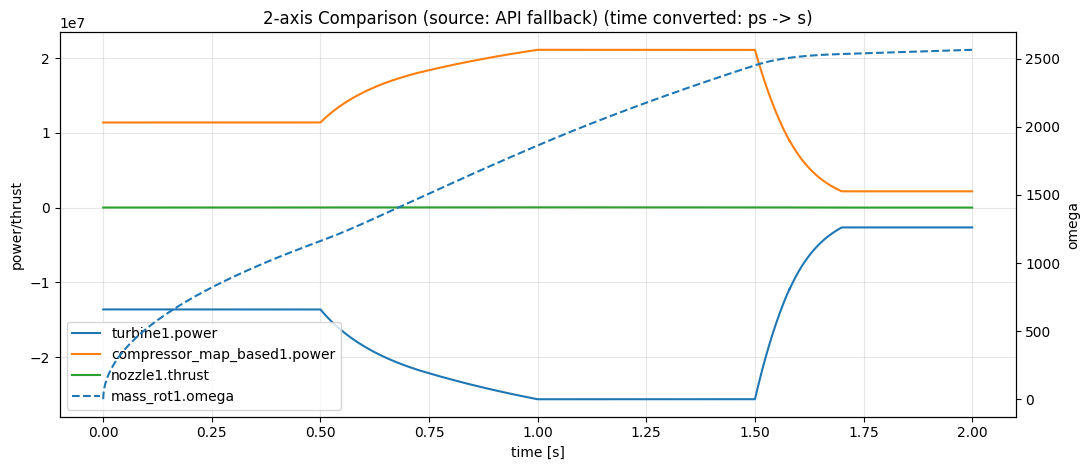

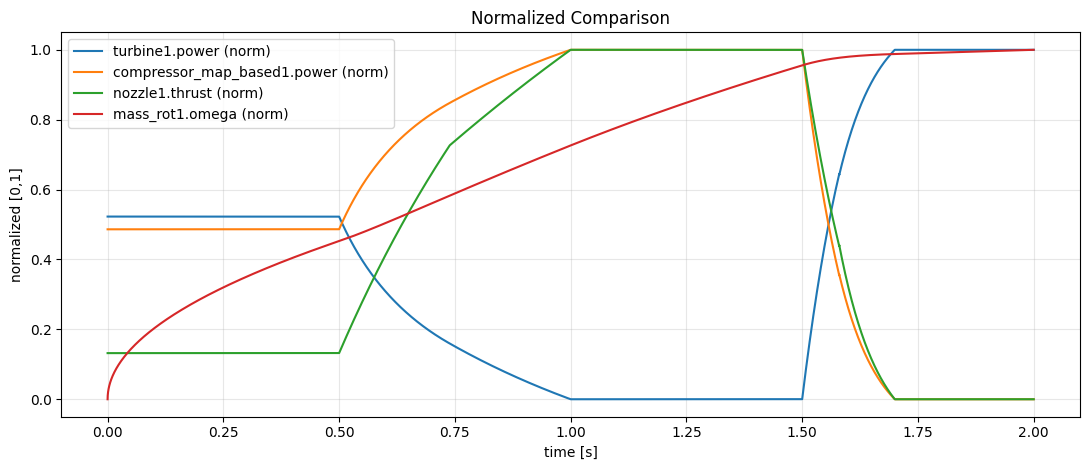

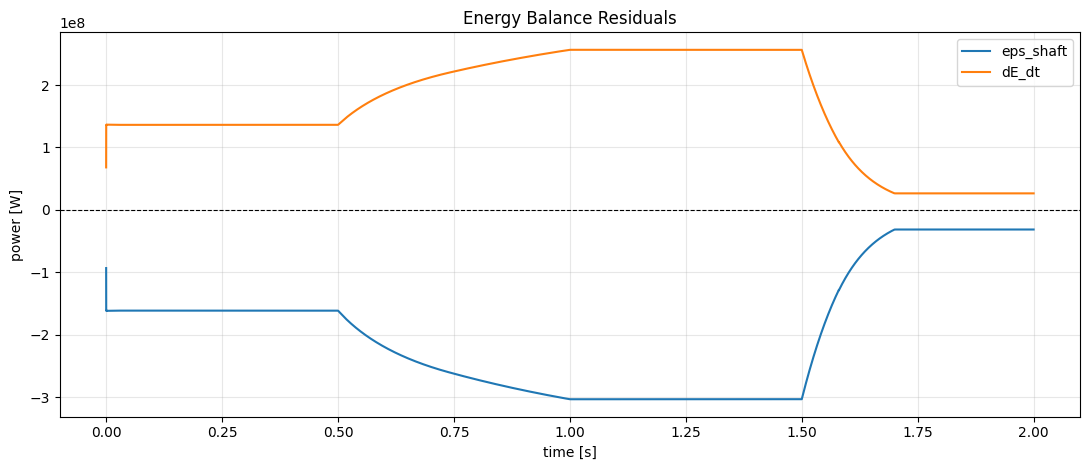

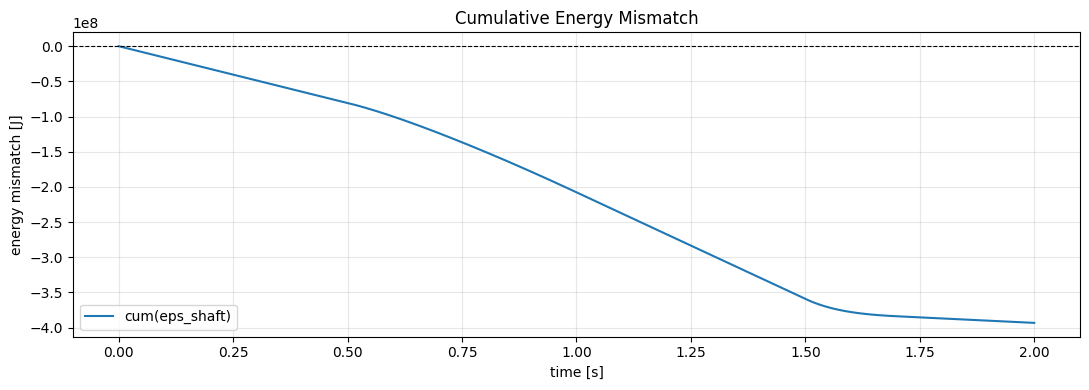

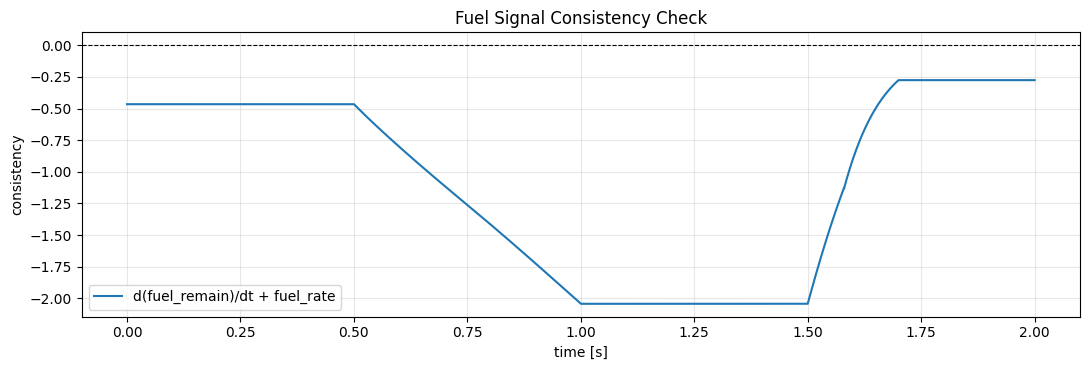

source: API fallback
2-axis left: ['turbine1.power', 'compressor_map_based1.power', 'nozzle1.thrust']
2-axis right: ['mass_rot1.omega']
normalized: ['turbine1.power', 'compressor_map_based1.power', 'nozzle1.thrust', 'mass_rot1.omega']
energy cols: ['eps_shaft', 'dE_dt']
mean(|eps_shaft|): 194600309.585244
mean(|fuel_consistency|): 1.0580806411785266
notes:
 - fuel_rate(remain), velocity, power 신호 부족으로 eps_total은 계산하지 않았습니다.


In [64]:
# result/cmp_df/API fallback + 2축/정규화/에너지보존 플롯 (fuel_rate/fuel_remain 통합)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _to_df(obj):
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if isinstance(obj, dict):
        return pd.DataFrame(obj)
    if hasattr(obj, "to_pandas"):
        return obj.to_pandas()
    return pd.DataFrame(obj)


def _collect_map_metrics_from_api(tb_obj):
    """Map design에서 주요 시계열을 API로 수집해 DataFrame으로 반환."""
    active0 = tb_obj.design_name
    map_design = None
    for d in tb_obj.design_list:
        if "map" in str(d).lower():
            map_design = d
            break
    if map_design is None:
        raise RuntimeError(f"map design을 찾지 못했습니다: {tb_obj.design_list}")

    if map_design != active0:
        tb_obj.set_active_design(map_design)

    try:
        exprs = tb_obj.post.available_report_quantities(solution="TR", quantities_category="All") or []

        def _pick(all_exprs, *keys):
            for e in all_exprs:
                el = str(e).lower()
                if all(k in el for k in keys):
                    return str(e)
            return None

        candidates = [
            _pick(exprs, "turbine", "power"),
            _pick(exprs, "compressor", "power"),
            _pick(exprs, "nozzle", "thrust"),
            _pick(exprs, "mass_rot", "omega"),
            _pick(exprs, "ramp", "vel"),
            _pick(exprs, "flight", "vel"),
            _pick(exprs, "fuel", "rate"),
            _pick(exprs, "fuel", "remain"),
            _pick(exprs, "fuel", "flow"),
            _pick(exprs, "mflow", "fuel"),
        ]
        selected = [e for e in candidates if e]
        if not selected:
            raise RuntimeError("플롯할 표현식을 찾지 못했습니다.")

        sd0 = tb_obj.post.get_solution_data(expressions=[selected[0]], setup_sweep_name="TR", domain="Time")
        t = np.array(sd0.primary_sweep_values, dtype=float)
        out = {"time": t}

        for expr in selected:
            sd = tb_obj.post.get_solution_data(expressions=[expr], setup_sweep_name="TR", domain="Time")
            y = np.array(sd.data_real(expr), dtype=float)
            n = min(len(t), len(y))
            col = expr.replace("\n", " ").strip()
            out[col] = y[:n]

        nmin = min(len(v) for v in out.values())
        for k in list(out.keys()):
            out[k] = np.asarray(out[k])[:nmin]

        return pd.DataFrame(out)
    finally:
        if map_design != active0:
            tb_obj.set_active_design(active0)


def _find_col(cols, *keys):
    for c in cols:
        cl = str(c).lower()
        if all(k in cl for k in keys):
            return c
    return None


# 1) 기존 결과 변수 재사용
candidate_names = ["result", "results", "cmp_df", "map_df", "result_df", "sim_df", "df_result"]
df = None
src_name = None
for name in candidate_names:
    if name in globals():
        try:
            tmp = _to_df(globals()[name])
            if isinstance(tmp, pd.DataFrame) and (not tmp.empty):
                df = tmp
                src_name = name
                break
        except Exception:
            pass

# 2) fallback: API 수집
if df is None:
    tb_obj = globals().get("tb", None) or globals().get("tb_map", None)
    if tb_obj is None:
        raise NameError("사용 가능한 결과 변수(result/cmp_df 등)도 없고 tb/tb_map 객체도 없습니다.")
    df = _collect_map_metrics_from_api(tb_obj)
    src_name = "API fallback"

# 공통 준비
x_col = "time" if "time" in df.columns else None
if x_col is None:
    x_candidates = [c for c in df.columns if str(c).lower() in ("time", "t", "simtime")]
    x_col = x_candidates[0] if x_candidates else None

num_cols = list(df.select_dtypes(include=[np.number]).columns)
if x_col in num_cols:
    num_cols.remove(x_col)
if not num_cols:
    raise ValueError("플롯 가능한 숫자 컬럼이 없습니다.")

x_raw = df[x_col].to_numpy(dtype=float) if x_col is not None else np.arange(len(df), dtype=float)
x_span = float(np.nanmax(x_raw) - np.nanmin(x_raw)) if len(x_raw) else 0.0

# 시간축 스케일 자동 보정: ps 단위로 보이면 s로 환산
if x_span > 1.0e6:
    x = x_raw * 1.0e-12
    x_unit_note = "(time converted: ps -> s)"
else:
    x = x_raw
    x_unit_note = ""

# 3) 2축(y-axis) 플롯
power_cols = [c for c in num_cols if re.search(r"power", str(c), flags=re.IGNORECASE)]
thrust_cols = [c for c in num_cols if re.search(r"thrust", str(c), flags=re.IGNORECASE)]
omega_cols = [c for c in num_cols if re.search(r"omega", str(c), flags=re.IGNORECASE)]

left_cols = (power_cols + thrust_cols)[:3] if (power_cols or thrust_cols) else num_cols[:2]
right_cols = omega_cols[:2]

fig, ax1 = plt.subplots(figsize=(11, 4.8))
for c in left_cols:
    ax1.plot(x, df[c].to_numpy(dtype=float), label=str(c), linewidth=1.5)
ax1.set_xlabel("time [s]")
ax1.set_ylabel("power/thrust")
ax1.grid(True, alpha=0.3)

if right_cols:
    ax2 = ax1.twinx()
    for c in right_cols:
        ax2.plot(x, df[c].to_numpy(dtype=float), linestyle="--", linewidth=1.5, label=str(c))
    ax2.set_ylabel("omega")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
else:
    ax1.legend(loc="best")

plt.title(f"2-axis Comparison (source: {src_name}) {x_unit_note}")
plt.tight_layout()
plt.show()

# 4) 정규화(min-max) 플롯
norm_cols = list(dict.fromkeys(left_cols + right_cols))
if not norm_cols:
    norm_cols = num_cols[: min(4, len(num_cols))]

plt.figure(figsize=(11, 4.8))
for c in norm_cols:
    y = df[c].to_numpy(dtype=float)
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    if np.isfinite(ymin) and np.isfinite(ymax) and ymax > ymin:
        yn = (y - ymin) / (ymax - ymin)
    else:
        yn = np.zeros_like(y)
    plt.plot(x, yn, label=f"{c} (norm)", linewidth=1.5)

plt.xlabel("time [s]")
plt.ylabel("normalized [0,1]")
plt.title("Normalized Comparison")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 5) 에너지형태 잔차 플롯
# eps_shaft = P_turbine - P_compressor - d/dt(0.5*J*omega^2)
# eps_total = mdot_f*LHV - (P_comp + T*V + dE/dt)

cols = list(df.columns)
c_turb_p = _find_col(cols, "turbine", "power")
c_comp_p = _find_col(cols, "compressor", "power")
c_thrust = _find_col(cols, "nozzle", "thrust")
c_omega = _find_col(cols, "mass_rot", "omega") or _find_col(cols, "omega")
c_vel = _find_col(cols, "ramp", "vel") or _find_col(cols, "flight", "vel") or _find_col(cols, "vel")

# fuel 관련: rate 우선, 없으면 remain 미분으로 추정
c_fuel_rate = _find_col(cols, "fuel", "rate")
c_fuel_remain = _find_col(cols, "fuel", "remain")
if c_fuel_rate is None:
    c_fuel_rate = _find_col(cols, "fuel", "flow") or _find_col(cols, "mflow", "fuel")

energy_df = pd.DataFrame({"time": x})
notes = []

# dE/dt
if c_omega is not None:
    omega = df[c_omega].to_numpy(dtype=float)
    J_eq = 101.0
    E_kin = 0.5 * J_eq * omega**2
    dE_dt = np.gradient(E_kin, x, edge_order=1)
    energy_df["E_kin"] = E_kin
    energy_df["dE_dt"] = dE_dt
else:
    dE_dt = None
    notes.append("omega 신호가 없어 dE/dt 계산을 생략했습니다.")

# shaft residual
if (c_turb_p is not None) and (c_comp_p is not None) and (dE_dt is not None):
    P_turb = df[c_turb_p].to_numpy(dtype=float)
    P_comp = df[c_comp_p].to_numpy(dtype=float)
    eps_shaft = P_turb - P_comp - dE_dt
    energy_df["eps_shaft"] = eps_shaft
else:
    notes.append("turbine/compressor power 또는 dE/dt 부족으로 eps_shaft 일부 생략.")

# mdot_f 생성
mdot_f = None
if c_fuel_rate is not None:
    mdot_f = df[c_fuel_rate].to_numpy(dtype=float)
    # 값이 너무 크면 kg/h -> kg/s로 가정
    med = np.nanmedian(np.abs(mdot_f)) if np.isfinite(np.nanmedian(np.abs(mdot_f))) else np.nan
    if np.isfinite(med) and med > 1.0:
        mdot_f = mdot_f / 3600.0
        notes.append(f"fuel_rate를 kg/h로 가정하고 kg/s로 변환했습니다: {c_fuel_rate}")
    energy_df["mdot_f"] = mdot_f

if (mdot_f is None) and (c_fuel_remain is not None):
    fuel_remain = df[c_fuel_remain].to_numpy(dtype=float)
    mdot_f = -np.gradient(fuel_remain, x, edge_order=1)
    energy_df["mdot_f_from_remain"] = mdot_f
    notes.append(f"fuel_rate가 없어 fuel_remain 미분으로 mdot_f를 추정했습니다: {c_fuel_remain}")

# fuel consistency: d(fuel_remain)/dt + mdot_f
if (c_fuel_remain is not None) and (mdot_f is not None):
    fuel_remain = df[c_fuel_remain].to_numpy(dtype=float)
    fuel_consistency = np.gradient(fuel_remain, x, edge_order=1) + mdot_f
    energy_df["fuel_consistency"] = fuel_consistency

# total residual
if (mdot_f is not None) and (c_comp_p is not None) and (c_thrust is not None) and (c_vel is not None) and (dE_dt is not None):
    LHV = 43e6  # J/kg
    P_in = mdot_f * LHV
    P_comp = df[c_comp_p].to_numpy(dtype=float)
    P_prop = df[c_thrust].to_numpy(dtype=float) * df[c_vel].to_numpy(dtype=float)
    eps_total = P_in - (P_comp + P_prop + dE_dt)
    energy_df["P_in_fuel"] = P_in
    energy_df["P_prop_TV"] = P_prop
    energy_df["eps_total"] = eps_total
else:
    notes.append("fuel_rate(remain), velocity, power 신호 부족으로 eps_total은 계산하지 않았습니다.")

# 5-a) 잔차 파워 플롯
plot_energy_cols = [c for c in ["eps_shaft", "eps_total", "dE_dt"] if c in energy_df.columns]
if plot_energy_cols:
    plt.figure(figsize=(11, 4.8))
    for c in plot_energy_cols:
        plt.plot(energy_df["time"], energy_df[c], label=c, linewidth=1.5)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8)
    plt.xlabel("time [s]")
    plt.ylabel("power [W]")
    plt.title("Energy Balance Residuals")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# 5-b) 누적 에너지 불일치
    plt.figure(figsize=(11, 4.0))
    dt = np.gradient(energy_df["time"].to_numpy(dtype=float), edge_order=1)
    for c in ["eps_shaft", "eps_total"]:
        if c in energy_df.columns:
            cumE = np.cumsum(energy_df[c].to_numpy(dtype=float) * dt)
            plt.plot(energy_df["time"], cumE, label=f"cum({c})", linewidth=1.5)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8)
    plt.xlabel("time [s]")
    plt.ylabel("energy mismatch [J]")
    plt.title("Cumulative Energy Mismatch")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("에너지 보존 잔차 플롯을 만들 수 있는 신호가 부족합니다.")

# 5-c) 연료 일관성 플롯
if "fuel_consistency" in energy_df.columns:
    plt.figure(figsize=(11, 3.8))
    plt.plot(energy_df["time"], energy_df["fuel_consistency"], label="d(fuel_remain)/dt + fuel_rate", linewidth=1.5)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8)
    plt.xlabel("time [s]")
    plt.ylabel("consistency")
    plt.title("Fuel Signal Consistency Check")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# 6) 요약 지표
print("source:", src_name)
print("2-axis left:", [str(c) for c in left_cols])
print("2-axis right:", [str(c) for c in right_cols])
print("normalized:", [str(c) for c in norm_cols])
print("energy cols:", [str(c) for c in plot_energy_cols])

if "eps_total" in energy_df.columns:
    eps = energy_df["eps_total"].to_numpy(dtype=float)
    print("mean(|eps_total|):", float(np.nanmean(np.abs(eps))))
if "eps_shaft" in energy_df.columns:
    eps = energy_df["eps_shaft"].to_numpy(dtype=float)
    print("mean(|eps_shaft|):", float(np.nanmean(np.abs(eps))))
if "fuel_consistency" in energy_df.columns:
    fc = energy_df["fuel_consistency"].to_numpy(dtype=float)
    print("mean(|fuel_consistency|):", float(np.nanmean(np.abs(fc))))

if notes:
    print("notes:")
    for n in notes:
        print(" -", n)


In [65]:
# ═══════════════════════════════════════════════════════════════════════════
# 기본 모델 "Gas Turbine Engine" 에너지보존 / 파워평형 검증
# ═══════════════════════════════════════════════════════════════════════════
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1) 기본 디자인으로 전환 & 사용 가능 신호 확인 ──────────────────────────
tb.set_active_design("Gas Turbine Engine")
print(f"Active design: {tb.design_name}")

exprs_all = tb.post.available_report_quantities(
    solution="TR", quantities_category="All"
) or []

# 관심 키워드별 표현식 매칭
def _pick(all_exprs, *keys):
    for e in all_exprs:
        el = str(e).lower()
        if all(k in el for k in keys):
            return str(e)
    return None

sig = {
    "P_turbine":  _pick(exprs_all, "turbine", "power"),
    "P_compressor": _pick(exprs_all, "compressor", "power"),
    "omega_shaft": _pick(exprs_all, "shaft", "omega"),
    "omega_mass":  _pick(exprs_all, "mass_rot", "omega"),
    "tau_turbine": _pick(exprs_all, "turbine", "tau"),
    "tau_comp":    _pick(exprs_all, "compressor", "tau"),
    "tau_shaft":   _pick(exprs_all, "shaft", "tau"),
    "thrust":      _pick(exprs_all, "nozzle", "thrust"),
    "fuel_rate":   _pick(exprs_all, "fuel", "rate") or _pick(exprs_all, "fuel", "flow"),
}

print("\n=== 매칭된 신호 ===")
for k, v in sig.items():
    print(f"  {k:15s} → {v}")

# 매칭 안된 것 중 power/omega/tau 포함 표현식 탐색
print("\n=== power/omega/tau 포함 가용 표현식 (참고) ===")
for e in exprs_all:
    el = str(e).lower()
    if any(kw in el for kw in ("power", "omega", "tau", "torque", "thrust")):
        print(f"  {e}")


PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Returning found Desktop session with PID 55952!
PyAEDT INFO: Project GT_Engine set to active.
PyAEDT INFO: Active Design set to 0;Gas Turbine Engine
PyAEDT INFO: AEDT objects correctly read
Active design: Gas Turbine Engine
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 3sec

=== 매칭된 신호 ===
  P_turbine       → turbine1.power
  P_compressor    → compressor1.power
  omega_shaft     → None
  omega_mass      → mass_rot1.omega
  tau_turbine     → None
  tau_comp        → None
  tau_shaft       → None
  thrust          → nozzle1.thrust
  fuel_rate       → fueltank1.fuel_rate

=== power/omega/tau 포함 가용 표현식 (참고) ===
  compressor1.power
  mass_rot1.omega
  nozzle1.thrust
  turbine1.power


In [66]:
# ── 2) 시계열 데이터 수집 ─────────────────────────────────────────────────
selected_exprs = [v for v in sig.values() if v is not None]
print(f"수집할 표현식 수: {len(selected_exprs)}")

# 시간축 기준
sd0 = tb.post.get_solution_data(
    expressions=[selected_exprs[0]], setup_sweep_name="TR", domain="Time"
)
t_raw = np.array(sd0.primary_sweep_values, dtype=float)

# 시간 스케일 자동 보정 (ps→s)
t_span = float(np.nanmax(t_raw) - np.nanmin(t_raw))
if t_span > 1e6:
    t = t_raw * 1e-12
    print(f"시간축 스케일: ps → s 변환 (span={t_span:.2e} → {t[-1]:.4f} s)")
else:
    t = t_raw
    print(f"시간축: {t[0]:.4f} ~ {t[-1]:.4f} s")

# 각 신호 수집
data = {"time": t}
for name, expr in sig.items():
    if expr is None:
        continue
    sd = tb.post.get_solution_data(expressions=[expr], setup_sweep_name="TR", domain="Time")
    y = np.array(sd.data_real(expr), dtype=float)
    n = min(len(t), len(y))
    data[name] = y[:n]

# 길이 맞추기
nmin = min(len(v) for v in data.values())
for k in data:
    data[k] = np.asarray(data[k])[:nmin]
t = data["time"]

edf = pd.DataFrame(data)
print(f"\n수집 완료: {len(edf)} steps, columns = {list(edf.columns)}")
edf.describe()


수집할 표현식 수: 5
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
시간축 스케일: ps → s 변환 (span=2.00e+12 → 2.0000 s)
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec

수집 완료: 2132 steps, columns = ['time', 'P_turbine', 'P_compressor', 'omega_mass', 'thrust', 'fuel_rate']


,time,P_turbine,P_compressor,omega_mass,thrust,fuel_rate
count,2132.000000,2.132000e+03,2.132000e+03,2132.000000,2132.000000,2132.000000
mean,0.961181,-1.874090e+07,1.549620e+07,1864.154136,33588.071046,-1.305586
std,0.600295,8.124610e+06,6.706454e+06,777.727134,14968.216904,0.722803
min,0.000000,-2.554225e+07,2.062554e+06,0.000000,5891.934313,-2.277838
25%,0.439363,-2.542235e+07,1.690445e+07,1328.111900,31142.228913,-2.226267
50%,0.961826,-2.027375e+07,1.690445e+07,2032.365641,31151.628089,-1.008171
75%,1.494576,-2.027375e+07,2.089563e+07,2612.324398,49410.350986,-0.864436
max,2.000000,-2.516992e+06,2.098127e+07,2720.702621,49994.761961,-0.286955


C:\Users\user\AppData\Local\Temp\ipykernel_35996\1136239830.py:99: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_35996\1136239830.py:99: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_35996\1136239830.py:99: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_35996\1136239830.py:99: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\IPython\core\pylab

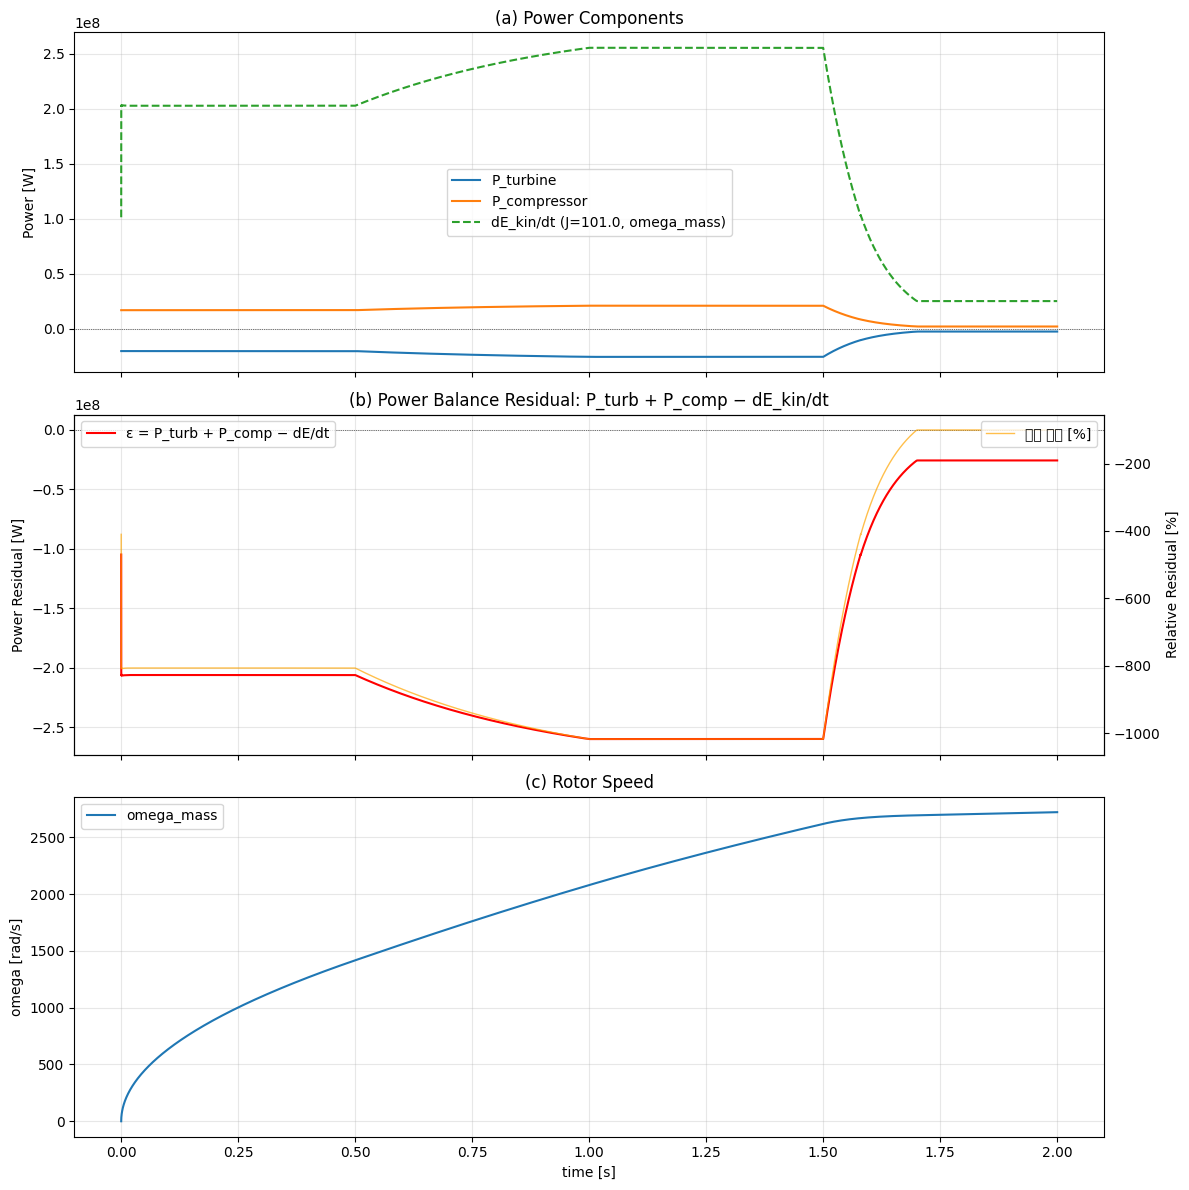


  기본 모델 에너지보존 검증 요약
  ω 사용 신호:      omega_mass
  J_total:           101.0 kg·m²
  |P_turbine| max:   2.55e+07 W
  |P_compressor| max:2.10e+07 W
  |dE/dt| max:       2.55e+08 W
  |ε| mean:          1.91e+08 W
  |ε| max:           2.60e+08 W
  |ε/P_turb| mean:   745.92 %

  ✗ 파워 평형 불성립 (잔차 745.9%)
    → 모델이 에너지보존을 명시적으로 강제하지 않음
    → 또는 부호 규약/누락 항 확인 필요


In [67]:
# ── 3) 파워 평형 분석 & 플롯 ──────────────────────────────────────────────
# =========================================================================
# VHDL-AMS 기본 모델 파워 관계:
#   turbine:     P_turb = omega * tau_turb   (tau_turb > 0 → 에너지 공급)
#   compressor:  P_comp = omega * tau_comp   (tau_comp < 0 → 에너지 소비)
#   shaft:       J_shaft * d(omega)/dt = sum(tau)
#   mass_rot:    J_mass * d(omega)/dt = sum(tau)
#
# 이상적 파워 평형:
#   P_turbine + P_compressor = d/dt(E_kinetic)  (= J_total * omega * d(omega)/dt)
# =========================================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# --- (a) 파워 시계열 비교 ---
ax = axes[0]
has_power = False
if "P_turbine" in edf.columns:
    ax.plot(t, edf["P_turbine"], label="P_turbine", linewidth=1.5)
    has_power = True
if "P_compressor" in edf.columns:
    ax.plot(t, edf["P_compressor"], label="P_compressor", linewidth=1.5)
    has_power = True

# dE/dt 계산
omega_col = "omega_mass" if "omega_mass" in edf.columns else ("omega_shaft" if "omega_shaft" in edf.columns else None)
if omega_col:
    omega_arr = edf[omega_col].to_numpy(dtype=float)
    # J = J_shaft(1) + J_mass_rot(100) = 101
    J_total = 101.0
    E_kin = 0.5 * J_total * omega_arr**2
    dEdt = np.gradient(E_kin, t, edge_order=1)
    ax.plot(t, dEdt, label=f"dE_kin/dt (J={J_total}, {omega_col})", linewidth=1.5, linestyle="--")
    has_power = True

if has_power:
    ax.axhline(0, color="k", linewidth=0.5, linestyle=":")
    ax.set_ylabel("Power [W]")
    ax.set_title("(a) Power Components")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

# --- (b) 파워 평형 잔차 ---
ax = axes[1]
residual_computed = False

if ("P_turbine" in edf.columns) and ("P_compressor" in edf.columns) and (omega_col is not None):
    P_turb_arr = edf["P_turbine"].to_numpy(dtype=float)
    P_comp_arr = edf["P_compressor"].to_numpy(dtype=float)
    
    # 부호 규약: P_turb > 0 (공급), P_comp < 0 (소비)
    # 파워 밸런스: P_turb + P_comp - dE/dt = 0 이면 보존
    eps_power = P_turb_arr + P_comp_arr - dEdt
    
    ax.plot(t, eps_power, label="ε = P_turb + P_comp − dE/dt", linewidth=1.5, color="red")
    ax.axhline(0, color="k", linewidth=0.5, linestyle=":")
    
    # 상대 잔차 (P_turb 기준)
    P_scale = np.nanmax(np.abs(P_turb_arr))
    if P_scale > 0:
        eps_rel = eps_power / P_scale * 100
        ax2b = ax.twinx()
        ax2b.plot(t, eps_rel, label="상대 잔차 [%]", linewidth=1, color="orange", alpha=0.7)
        ax2b.set_ylabel("Relative Residual [%]")
        ax2b.legend(loc="upper right")
    
    ax.set_ylabel("Power Residual [W]")
    ax.set_title("(b) Power Balance Residual: P_turb + P_comp − dE_kin/dt")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    residual_computed = True
else:
    ax.text(0.5, 0.5, "P_turbine, P_compressor, omega 중 일부 신호 없음",
            transform=ax.transAxes, ha="center", fontsize=12)

# --- (c) 토크 평형 (만약 tau 신호 있으면) ---
ax = axes[2]
tau_cols = [k for k in edf.columns if "tau" in k]
if tau_cols and omega_col:
    for tc in tau_cols:
        ax.plot(t, edf[tc], label=tc, linewidth=1.5)
    # d(omega)/dt * J
    domega_dt = np.gradient(omega_arr, t, edge_order=1)
    ax.plot(t, J_total * domega_dt, label=f"J·dω/dt (J={J_total})", linewidth=1.5, linestyle="--", color="black")
    ax.axhline(0, color="k", linewidth=0.5, linestyle=":")
    ax.set_ylabel("Torque [N·m]")
    ax.set_title("(c) Torque Balance: Στ vs J·dω/dt")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
elif omega_col:
    # tau 없으면 omega 그래프
    ax.plot(t, omega_arr, label=omega_col, linewidth=1.5)
    ax.set_ylabel("omega [rad/s]")
    ax.set_title("(c) Rotor Speed")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

ax.set_xlabel("time [s]")
plt.tight_layout()
plt.show()

# ── 4) 정량 요약 ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  기본 모델 에너지보존 검증 요약")
print("="*60)
if residual_computed:
    print(f"  ω 사용 신호:      {omega_col}")
    print(f"  J_total:           {J_total} kg·m²")
    print(f"  |P_turbine| max:   {np.nanmax(np.abs(P_turb_arr)):.2e} W")
    print(f"  |P_compressor| max:{np.nanmax(np.abs(P_comp_arr)):.2e} W")
    print(f"  |dE/dt| max:       {np.nanmax(np.abs(dEdt)):.2e} W")
    print(f"  |ε| mean:          {np.nanmean(np.abs(eps_power)):.2e} W")
    print(f"  |ε| max:           {np.nanmax(np.abs(eps_power)):.2e} W")
    print(f"  |ε/P_turb| mean:   {np.nanmean(np.abs(eps_power))/P_scale*100:.2f} %")
    
    if np.nanmean(np.abs(eps_power))/P_scale < 0.01:
        print("\n  ✓ 파워 평형 양호 (잔차 < 1%)")
    elif np.nanmean(np.abs(eps_power))/P_scale < 0.05:
        print("\n  △ 파워 평형 근사적 성립 (잔차 1~5%)")
    else:
        print(f"\n  ✗ 파워 평형 불성립 (잔차 {np.nanmean(np.abs(eps_power))/P_scale*100:.1f}%)")
        print("    → 모델이 에너지보존을 명시적으로 강제하지 않음")
        print("    → 또는 부호 규약/누락 항 확인 필요")
else:
    print("  필요한 신호가 부족하여 정량 검증 불가")

# 토크 밸런스 검증
if tau_cols and omega_col:
    tau_sum = sum(edf[tc].to_numpy(dtype=float) for tc in tau_cols)
    J_domega = J_total * domega_dt
    eps_tau = tau_sum - J_domega
    print(f"\n  토크 밸런스: Σ({', '.join(tau_cols)}) - J·dω/dt")
    print(f"  |ε_τ| mean:        {np.nanmean(np.abs(eps_tau)):.2e} N·m")
    print(f"  |ε_τ| max:         {np.nanmax(np.abs(eps_tau)):.2e} N·m")
print("="*60)


In [18]:
import os
import ansys.aedt.core as app

# ── ① Gas Turbine Engine_Map 디자인으로 전환 ─────────────────────────
tb_map = app.TwinBuilder(
    project='GT_Engine',
    design='Gas Turbine Engine_Map',
    non_graphical=NG_MODE,
    new_desktop=False,
    version=AEDT_VERSION,
)
editor = tb_map.odesign.SetActiveEditor('SchematicEditor')
schematic = tb_map.modeler.schematic
print('Connected to design:', tb_map.design_name)

# # ── ② compressor_map_based_v2.vhd 임포트 ─────────────────────────────
# vhd_v2 = r'E:\KDH\gitPyAEDT_MoaEM\pyAEDT_MoaEM\AEDT\TwinBuilder\vhdl\compressor_map_based_v2.vhd'
# schematic.ocomponent_manager.ImportModelsFromFile(vhd_v2)
# print(f'Imported v2 VHD: {vhd_v2}')
# print('Available models (first 10):', list(schematic.ocomponent_manager.GetNames())[:10])

PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Returning found Desktop session with PID 55952!
PyAEDT INFO: Project GT_Engine set to active.
PyAEDT INFO: Active Design set to 129;Gas Turbine Engine_Map
PyAEDT INFO: AEDT objects correctly read
PyAEDT INFO: ModelerCircuit class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: ModelerTwinBuilder class has been initialized!
Connected to design: Gas Turbine Engine_Map


In [19]:
schematic.components.items()

dict_items([(6, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (8, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (10, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (12, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (16, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (18, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (20, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (22, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (24, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (316, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (188, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (510, Class: ansys.aedt.core.modeler.circuits.object_3d_circuit.CircuitComponent), (52

In [24]:
_id0, comp0 = next(iter(schematic.components.items()))

In [ ]:
first_key, first_val = list(schematic.components.items())[0]
items = list(schematic.components.items())
if items:
    first_key, first_val = items[0]
else:
    print("components 비어있음")
items = list(schematic.components.items())
name_list = list(map(lambda kv: kv[1].name, items[:]))
name_list[13]
items[13][1].parameters

In [ ]:
# items[13][1].parameters flatten (pyaedt_twinbuilder 방식)
import pandas as pd
from pyaedt_twinbuilder._utils import flatten_aedt_data

items = list(schematic.components.items())
idx = 13

if len(items) <= idx:
    raise IndexError(f"items[{idx}] 접근 불가: 전체 길이={len(items)}")

comp_obj = items[idx][1]
inst_name = getattr(comp_obj, "name", str(items[idx][0]))

# 1) comp_obj.parameters 원본
raw_params = getattr(comp_obj, "parameters", None)

# 2) pyaedt_twinbuilder 스타일 flatten
flat_from_attr = flatten_aedt_data(raw_params)

# 3) fallback: editor 탭 raw를 flatten
flat_from_editor = {}
for tab in ["PassedParameterTab", "Quantities", "BaseElementTab"]:
    try:
        raw = editor.GetProperties(tab, inst_name)
        flat = flatten_aedt_data(raw)
        if flat:
            flat_from_editor.update({f"{tab}.{k}": v for k, v in flat.items()})
    except Exception:
        pass

# 4) dict/list 형태 보강
flat_extra = {}
if isinstance(raw_params, dict):
    flat_extra = {str(k): str(v) for k, v in raw_params.items()}
elif isinstance(raw_params, (list, tuple)):
    flat_extra = flatten_aedt_data(raw_params)

flat_all = {}
flat_all.update(flat_from_attr)
flat_all.update(flat_extra)
flat_all.update(flat_from_editor)

print(f"target index: {idx}")
print(f"instance    : {inst_name}")
print(f"component   : {getattr(comp_obj, 'component_name', '')}")
print(f"raw type    : {type(raw_params)}")
print(f"flatten keys: {len(flat_all)}")

if flat_all:
    df_params = pd.DataFrame(
        [{"key": k, "value": v} for k, v in flat_all.items()]
    ).sort_values("key").reset_index(drop=True)
    display(df_params)
else:
    print("flatten 결과가 비어 있습니다. raw 파라미터 구조를 확인하세요:")
    print(raw_params)


In [20]:
# -- 현재 디자인 컴포넌트 목록 추출
import pandas as pd

rows = []
for inst_name, comp_obj in schematic.components.items():
    row = {"instance": inst_name}
    try:
        info = editor.GetComponentInfo(inst_name)
        row["type"] = str(info[0]) if info else getattr(comp_obj, "component_name", "")
    except Exception:
        row["type"] = getattr(comp_obj, "component_name", "")
    try:
        pins = list(editor.GetComponentPins(inst_name))
        row["pins"] = ", ".join(pins); row["n_pins"] = len(pins)
    except Exception:
        row["pins"] = ""; row["n_pins"] = 0
    try:
        loc = getattr(comp_obj, "location", None) or getattr(comp_obj, "bounding_box", None)
        row["location"] = str(loc) if loc is not None else ""
    except Exception:
        row["location"] = ""
    rows.append(row)

df_comp = pd.DataFrame(rows, columns=["instance", "type", "n_pins", "pins", "location"])
df_comp = df_comp.sort_values("type").reset_index(drop=True)
print(f"총 컴포넌트 수: {len(df_comp)}")
display(df_comp)

총 컴포넌트 수: 14


,instance,type,n_pins,pins,location
0,6,,0,,"[0.0889, 0.04064]"
1,8,,0,,"[0.13208, 0.04826]"
2,10,,0,,"[0.16256, 0.04826]"
3,12,,0,,"[0.14224, 0.07366]"
4,16,,0,,"[0.10668, 0.0]"
5,18,,0,,"[-0.02794, -0.0127]"
6,20,,0,,"[-0.0254, 0.0]"
7,22,,0,,"[0.09398, 0.06604]"
8,24,,0,,"[0.18288, 0.09906]"
9,316,,0,,"[0.16256, 0.07366]"


In [ ]:
# ── ④ XY Characteristics LUT 블록 두 개 배치 + 데이터 설정 ─────────────────
# Simplorer Elements > Basic Elements > Tools > Characteristics > XY
# algebraic-loop 방지: LUT 입력은 omega만 사용 (mflow 금지)
OMEGA_DATA = [1000.0, 1500.0, 2000.0, 2500.0, 2800.0, 3000.0, 3500.0]
ETA_DATA   = [0.72,   0.76,   0.80,   0.83,   0.85,   0.84,   0.80]
PR_DATA    = [5.0,    5.8,    6.5,    7.3,    8.0,    8.2,    8.0]

LUT_COMP = 'XY'  # Simplorer Basic Elements > Tools > Characteristics

# compressor eta_in/pr_in 핀 기준 LUT 배치 좌표
try:
    eta_in_loc = get_pin_loc(COMP_INST, 'eta_in')
    pr_in_loc  = get_pin_loc(COMP_INST, 'pr_in')
    lut_x      = int(eta_in_loc[0]) - 3000
    lut_eta_y  = int(eta_in_loc[1])
    lut_pr_y   = int(pr_in_loc[1])
except Exception:
    lut_x, lut_eta_y, lut_pr_y = -5000, 500, -500
    print('[WARN] Pin location unavailable, using fallback coords')

lut_eta_inst = editor.CreateComponent(
    ['NAME:ComponentProps', 'Name:=', LUT_COMP, 'Id:=', ''],
    ['NAME:Attributes', 'Page:=', 1, 'X:=', lut_x, 'Y:=', lut_eta_y, 'Angle:=', 0, 'Flip:=', False],
)
lut_pr_inst = editor.CreateComponent(
    ['NAME:ComponentProps', 'Name:=', LUT_COMP, 'Id:=', ''],
    ['NAME:Attributes', 'Page:=', 1, 'X:=', lut_x, 'Y:=', lut_pr_y, 'Angle:=', 0, 'Flip:=', False],
)
print('lut_eta_inst:', lut_eta_inst)
print('lut_pr_inst :', lut_pr_inst)

# ── 프로퍼티 이름 자동 조회 ────────────────────────────────────────────────
# XY 컴포넌트 프로퍼티 탭 목록 확인
try:
    tabs = ['PassedParameterTab', 'BaseElementTab', 'Quantities']
    for tab in tabs:
        try:
            props = editor.GetProperties(tab, lut_eta_inst)
            if props:
                print(f'[{tab}] props:', list(props))
        except Exception:
            pass
except Exception as e:
    print('Property listing error:', e)

# ── 데이터 설정: XY Characteristics 프로퍼티 형식 ─────────────────────────
# XY 컴포넌트는 TABLE 또는 X/Y 별도 프로퍼티를 사용합니다.
# 아래는 두 가지 포맷을 순서대로 시도합니다.
def set_xy_data(inst, x_data, y_data, label):
    n = len(x_data)
    # Format A: TABLE 문자열 "N,x1,y1,x2,y2,..."  (ETABLE 호환)
    table_a = str(n) + ',' + ','.join(
        f'{float(x)},{float(y)}' for x, y in zip(x_data, y_data)
    )
    # Format B: X/Y 별도 문자열 (세미콜론 구분)
    x_str = '; '.join(str(float(v)) for v in x_data)
    y_str = '; '.join(str(float(v)) for v in y_data)

    # 시도 A: TABLE 단일 프로퍼티
    for prop_name in ['TABLE', 'Table', 'XYData', 'Data']:
        try:
            editor.ChangeProperty([
                'NAME:AllTabs',
                ['NAME:PassedParameterTab',
                 ['NAME:PropServers', inst],
                 ['NAME:ChangedProps', [f'NAME:{prop_name}', 'Value:=', table_a]]],
            ])
            print(f'  {label}: {prop_name} = OK  ({table_a[:40]}...)')
            return
        except Exception:
            pass

    # 시도 B: X / Y 별도 프로퍼티
    for xp, yp in [('X', 'Y'), ('XData', 'YData'), ('x', 'y')]:
        try:
            editor.ChangeProperty([
                'NAME:AllTabs',
                ['NAME:PassedParameterTab',
                 ['NAME:PropServers', inst],
                 ['NAME:ChangedProps',
                  [f'NAME:{xp}', 'Value:=', x_str],
                  [f'NAME:{yp}', 'Value:=', y_str]]],
            ])
            print(f'  {label}: {xp}/{yp} = OK')
            return
        except Exception:
            pass

    # 시도 C: N + 개별 포인트 설정
    try:
        changed = [[f'NAME:N', 'Value:=', str(n)]]
        for i, (x, y) in enumerate(zip(x_data, y_data), 1):
            changed.append([f'NAME:X{i}', 'Value:=', str(float(x))])
            changed.append([f'NAME:Y{i}', 'Value:=', str(float(y))])
        editor.ChangeProperty([
            'NAME:AllTabs',
            ['NAME:PassedParameterTab',
             ['NAME:PropServers', inst],
             ['NAME:ChangedProps', *changed]],
        ])
        print(f'  {label}: N+Xi+Yi = OK')
        return
    except Exception as e:
        pass

    print(f'  [WARN] {label}: 모든 포맷 실패 — 아래 props 목록 참고 후 수동 설정')

set_xy_data(lut_eta_inst, OMEGA_DATA, ETA_DATA, 'eta LUT')
set_xy_data(lut_pr_inst,  OMEGA_DATA, PR_DATA,  'PR  LUT')


In [ ]:
# ── ⑤ 배선 연결 ──────────────────────────────────────────────────────────
#  mass_rot1(omega) ──┬──> XY_eta(IN) ──> compressor(eta_in)
#                     └──> XY_PR (IN) ──> compressor(pr_in)
#
# XY Characteristics 핀 이름: 입력="IN", 출력="OUT"
# 실제 핀 이름이 다를 경우 셀 ③ 출력(get_pin_loc 실패 메시지)을 확인하고
# LUT_PIN_IN / LUT_PIN_OUT / OMEGA_PIN 을 수정하세요
LUT_PIN_IN  = 'IN'     # XY 입력 핀 (버전에 따라 'A', 'x', 'In' 등)
LUT_PIN_OUT = 'OUT'    # XY 출력 핀 (버전에 따라 'B', 'y', 'Out' 등)
OMEGA_PIN   = 'omega'  # mass_rot1 의 omega 출력 핀

# 핀 이름 자동 확인
for inst, label in [(lut_eta_inst, 'XY_eta'), (lut_pr_inst, 'XY_PR')]:
    try:
        pins = editor.GetComponentPins(inst)
        print(f'{label} pins:', list(pins))
    except Exception as e:
        print(f'{label} pin error:', e)

def wire(p1, p2):
    editor.CreateWire(
        ['NAME:WireData', 'NumberOfPoints:=', 2,
         'Points:=', [int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])]],
        ['NAME:Attributes', 'Page:=', 1],
    )

try:
    omega_loc    = get_pin_loc(SHAFT_INST,   OMEGA_PIN)
    eta_in_loc   = get_pin_loc(COMP_INST,    'eta_in')
    pr_in_loc    = get_pin_loc(COMP_INST,    'pr_in')
    lut_eta_in   = get_pin_loc(lut_eta_inst, LUT_PIN_IN)
    lut_eta_out  = get_pin_loc(lut_eta_inst, LUT_PIN_OUT)
    lut_pr_in    = get_pin_loc(lut_pr_inst,  LUT_PIN_IN)
    lut_pr_out   = get_pin_loc(lut_pr_inst,  LUT_PIN_OUT)

    # omega 신호를 두 LUT로 분기
    mid_y = (int(lut_eta_in[1]) + int(lut_pr_in[1])) // 2
    mid_x = int(omega_loc[0])
    wire(omega_loc,            (mid_x, mid_y))       # omega → 분기점
    wire((mid_x, mid_y),       lut_eta_in)           # 분기점 → XY_eta IN
    wire((mid_x, mid_y),       lut_pr_in)            # 분기점 → XY_PR  IN

    # LUT 출력 → compressor 포트
    wire(lut_eta_out, eta_in_loc)                    # XY_eta OUT → eta_in
    wire(lut_pr_out,  pr_in_loc)                     # XY_PR  OUT → pr_in

    print('배선 완료. AEDT GUI에서 회로 확인 후 Ctrl+S 저장')

except Exception as e:
    print(f'[ERROR] 배선 실패: {e}')
    print('핀 이름이 다를 경우 LUT_PIN_IN/OUT, OMEGA_PIN 상수를 확인하세요')

tb_map.save_project()
print('Project saved.')
